In [1]:
import lightkurve as lk
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from astropy.timeseries import LombScargle
import astropy.units as u
import gyrointerp
from gyrointerp import gyro_age_posterior
from gyrointerp import get_summary_statistics

targets = pd.read_csv("C:\\Users\\smithlt\\Documents\\ASTR502\\ASTR502_Mega_Target_List.csv")

In [6]:
#convert txt file to csv
k2_targets = pd.read_csv("C:\\Users\\smithlt\\Documents\\ASTR502\\K2_data_2.csv")

print(k2_targets.head())

     tic_ids  periods
0  257436461   33.122
1  435339847   20.686
2  337607207    8.733
3   39936432   29.439
4  392469577   17.988


In [7]:
#create an array of the K2 target TIC IDs
k2_target_tic_ids = k2_targets['tic_ids'].values
k2_target_periods = k2_targets['periods'].values

In [8]:
if 'mission_source' in targets.columns:
    print(f"\nMission sources in dataset:")
    print(targets['mission_source'].value_counts())
    
    # Filter for only K2 targets
    k2_targets_mega = targets[targets['mission_source'] == 'K2'].copy()
    print(f"\nFound {len(k2_targets_mega)} K2 targets!")

    # Clean tic_id: remove leading "TIC " if present and convert to numeric (coerce failures to NA)
    k2_targets_mega['tic_id'] = k2_targets_mega['tic_id'].astype(str).str.replace('TIC ', '', regex=False)
    k2_targets_mega['tic_id'] = pd.to_numeric(k2_targets_mega['tic_id'], errors='coerce').astype('Int64')
    print(k2_targets_mega['tic_id'].head())

    # If you have a list/array of TIC IDs to match, filter to those; otherwise keep all K2 targets
    if 'k2_target_tic_ids' in globals():
        # ensure k2_target_tic_ids are integers
        try:
            tic_list = [int(x) for x in k2_target_tic_ids]
        except Exception:
            tic_list = list(k2_target_tic_ids)
        matched = k2_targets[k2_targets['tic_ids'].isin(tic_list)].copy()
        matched_teff = k2_targets_mega[k2_targets_mega['tic_id'].isin(tic_list)].copy()
        print(f"\nMatched {len(matched)} K2 targets from provided TIC ID list.")
    else:
        matched = k2_targets.copy()
        print("\nNo external TIC ID list found; using all K2 targets.")

    # Build k2_star_df with columns required downstream: 'target_name', 'tic_id', 'Teff', 'period'
    target_results = []
    for idx, r in matched.iterrows():
        tic = int(r['tic_ids']) if pd.notnull(r['tic_ids']) else None
        target_name = r.get('pl_name') or r.get('hostname') or f"TIC{tic}"
        #have to get teff from the mega target list
        teff = matched_teff[matched_teff['tic_id'] == tic]['st_teff'].values
        lit_age = matched_teff[matched_teff['tic_id'] == tic]['st_age'].values

        #want to find the single period value for this tic id
        period = k2_targets['periods'][k2_targets['tic_ids'] == tic].values

        target_results.append({
            'tic_ids': target_name,
            'Teff': teff,
            'period': period,
            'st_age': lit_age
        })

    # create DataFrame even if empty so later cells won't raise NameError
    k2_star_df = pd.DataFrame(target_results, columns=['tic_ids', 'Teff', 'period', 'st_age'])
    print(f"\nFinal k2_star_df has {len(k2_star_df)} rows.")

else:
    # If no 'mission_source' column, create empty k2_star_df to avoid NameError later
    print("No 'mission_source' in targets DataFrame; creating empty k2_star_df.")
    k2_star_df = pd.DataFrame(columns=['target_name', 'tic_ids', 'Teff', 'period'])
    print(k2_star_df.head())


Mission sources in dataset:
mission_source
Kepler    2762
TESS       717
K2         548
WASP       168
HAT        139
Other      105
CoRoT       34
NGTS        22
KELT        21
Name: count, dtype: int64

Found 548 K2 targets!
32    318707987
33    318707987
38    429035886
44    257392778
45    405333767
Name: tic_id, dtype: Int64

Matched 105 K2 targets from provided TIC ID list.

Final k2_star_df has 105 rows.


In [9]:
Teff = k2_star_df['Teff']
print(Teff.head())
Prot = k2_star_df['period']
print(Prot.head())
lit_age = k2_star_df['st_age']
print(lit_age.head())

0            [4720.0]
1            [5160.0]
2    [5788.0, 5788.0]
3           [4348.35]
4    [5631.0, 5631.0]
Name: Teff, dtype: object
0    [33.122]
1    [20.686]
2     [8.733]
3    [29.439]
4    [17.988]
Name: period, dtype: object
0         [nan]
1         [4.7]
2    [nan, nan]
3         [nan]
4    [nan, nan]
Name: st_age, dtype: object


In [10]:
print(k2_star_df)

          tic_ids              Teff    period      st_age
0    TIC257436461          [4720.0]  [33.122]       [nan]
1    TIC435339847          [5160.0]  [20.686]       [4.7]
2    TIC337607207  [5788.0, 5788.0]   [8.733]  [nan, nan]
3     TIC39936432         [4348.35]  [29.439]       [nan]
4    TIC392469577  [5631.0, 5631.0]  [17.988]  [nan, nan]
..            ...               ...       ...         ...
100  TIC443616612  [3840.6, 3840.6]   [9.763]  [nan, nan]
101  TIC392817207          [3752.0]   [6.637]       [nan]
102  TIC432247315  [3810.0, 3810.0]  [10.868]  [nan, nan]
103  TIC903075188                []  [21.062]          []
104   TIC61312205          [3748.0]  [36.279]       [nan]

[105 rows x 4 columns]


In [11]:
# calculate dictionary of summary statistics for each target and store results in results_df
# Note: gyro_age_posterior and get_summary_statistics were imported in earlier cells,
# so we don't re-import them here.

# ensure columns exist (store arrays as objects)
for col in ['age_grid', 'age_posterior', 'median', '+1sigma', '-1sigma', 'mean', 'mode']:
    if col not in k2_star_df.columns:
        k2_star_df[col] = [None] * len(k2_star_df)

for i in range(k2_star_df.shape[0]):
    Prot = k2_star_df['period'].iloc[i]
    Prot_err = 0.2

    Teff = np.mean(k2_star_df['Teff'].iloc[i])
    Teff_err = 100

    # uniformly spaced grid between 0 and 4000 megayears
    age_grid = np.linspace(0, 4000, 500)

    # calculate the age posterior at each age in `age_grid`
    age_posterior = gyro_age_posterior(
        Prot, Teff,
        Prot_err=Prot_err, Teff_err=Teff_err,
        age_grid=age_grid
    )

    # compute summary statistics
    result = get_summary_statistics(age_grid, age_posterior)

    # store results in the dataframe
    k2_star_df.at[i, 'age_grid'] = age_grid
    k2_star_df.at[i, 'age_posterior'] = age_posterior
    k2_star_df.at[i, 'median'] = result.get('median', np.nan)
    k2_star_df.at[i, '+1sigma'] = result.get('+1sigma', np.nan)
    k2_star_df.at[i, '-1sigma'] = result.get('-1sigma', np.nan)
    k2_star_df.at[i, 'mean'] = result.get('mean', np.nan)
    k2_star_df.at[i, 'mode'] = result.get('mode', np.nan)

    print(f"\nTarget: {k2_star_df['tic_ids'].iloc[i]}")
    print(f"Age = {result['median']} +{result['+1sigma']} -{result['-1sigma']} Myr.")



Target: TIC257436461
Age = 3879.61 +87.75 -155.67 Myr.

Target: TIC435339847
Age = 2340.69 +208.91 -164.58 Myr.

Target: TIC337607207
Age = 801.53 +238.63 -117.46 Myr.

Target: TIC39936432
Age = 3821.65 +128.91 -217.23 Myr.

Target: TIC392469577
Age = 2360.18 +344.56 -271.57 Myr.

Target: TIC266014079
Age = 807.67 +186.96 -106.5 Myr.

Target: TIC14570099
Age = 3687.61 +202.4 -245.87 Myr.

Target: TIC179032688
Age = 3544.73 +264.08 -298.79 Myr.

Target: TIC376938120
Age = nan +nan -nan Myr.

Target: TIC187309502
Age = 2400.79 +233.47 -172.27 Myr.

Target: TIC333605244
Age = 3142.8 +281.1 -248.95 Myr.

Target: TIC366631954
Age = 2856.01 +264.8 -229.43 Myr.

Target: TIC307733361
Age = 292.61 +122.28 -100.97 Myr.

Target: TIC332022997
Age = 419.59 +142.23 -130.1 Myr.

Target: TIC238608004
Age = nan +nan -nan Myr.

Target: TIC376939759
Age = 3995.64 +2.98 -2.98 Myr.

Target: TIC418761354
Age = 3900.67 +73.13 -137.71 Myr.

Target: TIC293460551
Age = 3701.31 +196.29 -244.84 Myr.

Target: TIC

c:\Users\smithlt\miniconda3\envs\astr502\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\smithlt\miniconda3\envs\astr502\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



Target: TIC2521105
Age = nan +nan -nan Myr.

Target: TIC332024125
Age = 2465.02 +273.66 -222.09 Myr.

Target: TIC434226736
Age = nan +nan -nan Myr.

Target: TIC11023038
Age = 1986.23 +199.29 -149.04 Myr.

Target: TIC15756231
Age = 91.28 +193.54 -62.75 Myr.

Target: TIC12770870
Age = 2096.03 +287.74 -207.19 Myr.

Target: TIC86130229
Age = 957.56 +331.75 -150.01 Myr.

Target: TIC197246627
Age = 3995.03 +3.39 -4.8 Myr.

Target: TIC422349422
Age = 3774.66 +160.31 -250.83 Myr.

Target: TIC441907126
Age = 1553.78 +170.43 -120.81 Myr.

Target: TIC10195089
Age = 3995.64 +2.98 -2.98 Myr.

Target: TIC335102224
Age = 3995.63 +2.98 -2.98 Myr.

Target: TIC396972464
Age = 1950.57 +367.08 -244.02 Myr.

Target: TIC184914317
Age = nan +nan -nan Myr.

Target: TIC49652731
Age = 2785.09 +271.75 -233.4 Myr.

Target: TIC301258470
Age = 1207.98 +92.68 -86.88 Myr.

Target: TIC68504570
Age = 1181.01 +92.55 -86.27 Myr.

Target: TIC446672575
Age = 741.09 +336.25 -131.53 Myr.

Target: TIC291090078
Age = 1594.96 

c:\Users\smithlt\miniconda3\envs\astr502\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\smithlt\miniconda3\envs\astr502\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



Target: TIC903075188
Age = nan +nan -nan Myr.

Target: TIC61312205
Age = nan +nan -nan Myr.


In [13]:
#match these with st_age (ages from the literature) to see how well they compare 
k2_star_df  = k2_star_df.rename(columns={'tic_id': 'tic_ids'})
#k2_star_df = k2_star_df.astype({'tic_id': np.int64})
#k2_targets_mega = k2_targets_mega.astype({'tic_id': np.int64})
#k2_star_df = k2_star_df.merge(k2_targets_mega[["tic_id", "st_age"]], on="tic_id", how="left")


for i in range(len(k2_star_df)):
    lit_age = k2_star_df['st_age'].iloc[i]

    # Determine whether lit_age contains a usable value.
    # lit_age may be a scalar (float / pd.NA) or an array-like (np.ndarray, list, Series).
    if hasattr(lit_age, '__len__') and not np.isscalar(lit_age):
        # array-like: check length and that not all entries are NaN
        has_value = len(lit_age) > 0 and not np.all(pd.isna(lit_age))
        lit_age_repr = np.array2string(lit_age)
    else:
        # scalar: check for NaN / missing
        has_value = not pd.isna(lit_age)
        lit_age_repr = str(lit_age)

    if has_value:
        tic_col = 'tic_ids' if 'tic_ids' in k2_star_df.columns else 'tic_id'
        derived_age = k2_star_df['median'].iloc[i]
        age_uncertainty = k2_star_df['+1sigma'].iloc[i], k2_star_df['-1sigma'].iloc[i]
        print(f"Target: {k2_star_df[tic_col].iloc[i]}, Literature Age: {lit_age_repr} Gyr, Derived Age with Uncertainty: {derived_age} Myr ± {age_uncertainty[0]} Myr / {age_uncertainty[1]} Myr")

Target: TIC435339847, Literature Age: [4.7] Gyr, Derived Age with Uncertainty: 2340.69 Myr ± 208.91 Myr / 164.58 Myr
Target: TIC333605244, Literature Age: [6.9] Gyr, Derived Age with Uncertainty: 3142.8 Myr ± 281.1 Myr / 248.95 Myr
Target: TIC366631954, Literature Age: [6.2] Gyr, Derived Age with Uncertainty: 2856.01 Myr ± 264.8 Myr / 229.43 Myr
Target: TIC307733361, Literature Age: [0.75] Gyr, Derived Age with Uncertainty: 292.61 Myr ± 122.28 Myr / 100.97 Myr
Target: TIC376939759, Literature Age: [5.9] Gyr, Derived Age with Uncertainty: 3995.64 Myr ± 2.98 Myr / 2.98 Myr
Target: TIC2621212, Literature Age: [5.04 5.04] Gyr, Derived Age with Uncertainty: 1762.09 Myr ± 137.39 Myr / 115.91 Myr
Target: TIC175265494, Literature Age: [0.79] Gyr, Derived Age with Uncertainty: 892.48 Myr ± 154.58 Myr / 185.07 Myr
Target: TIC175194958, Literature Age: [0.79] Gyr, Derived Age with Uncertainty: nan Myr ± nan Myr / nan Myr
Target: TIC195193025, Literature Age: [0.79] Gyr, Derived Age with Uncertain

In [14]:
from gyrointerp.getters import _get_cluster_Prot_Teff_data
_get_cluster_Prot_Teff_data

clus_data = _get_cluster_Prot_Teff_data()

[W 260413 10:20:01 getters:72] No module named 'cdips'
[I 260413 10:20:01 getters:1551] Found c:\Users\smithlt\miniconda3\envs\astr502\Lib\site-packages\gyrointerp\data\interim\alpha-per\Boyle_table3_full_DR3_supp.csv; returning.
[I 260413 10:20:02 getters:1253] Found c:\Users\smithlt\miniconda3\envs\astr502\Lib\site-packages\gyrointerp\data\interim\psc-eri\Curtis_2019_X_GDR3_supplemented.csv, and not overwrite; returning.
[I 260413 10:20:02 getters:528] Found c:\Users\smithlt\miniconda3\envs\astr502\Lib\site-packages\gyrointerp\data\interim\blanco1\Gillen_2020_X_GDR3_supplemented.csv, and not overwrite; returning.
[I 260413 10:20:02 getters:663] Found c:\Users\smithlt\miniconda3\envs\astr502\Lib\site-packages\gyrointerp\data\interim\pleiades\Rebull_2016_X_GDR3_supplemented.csv, and not overwrite; returning.
[I 260413 10:20:02 getters:879] Found c:\Users\smithlt\miniconda3\envs\astr502\Lib\site-packages\gyrointerp\data\interim\ngc3532\Fritzewski_2021_X_DR3_supplemented.csv, and not ove

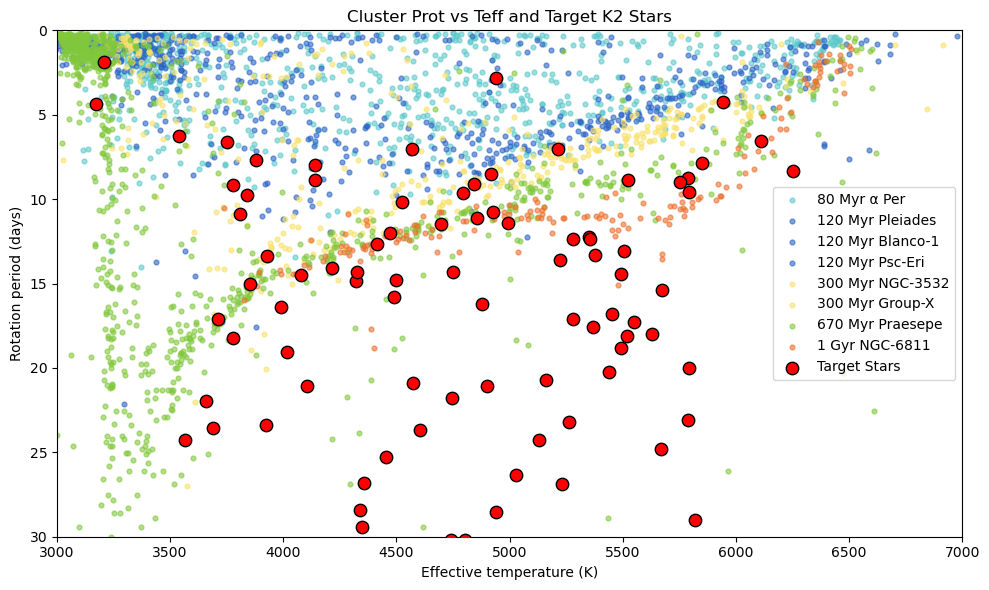

In [15]:
# plot the reference clusters (Prot vs Teff) and overplot our targets (period vs Teff)
reference_clusters = [
    'α Per', 'Pleiades', 'Blanco-1', 'Psc-Eri', 'NGC-3532', 'Group-X',
    'Praesepe', 'NGC-6811'
]

# Helper to convert stored entries (which may be arrays) to scalars for plotting
def _to_scalar_teff(teff):
    if teff is None:
        return np.nan
    arr = np.asarray(teff)
    if arr.size == 0:
        return np.nan
    # use the mean of available Teff values (safe if a small array of duplicates)
    return float(np.nanmean(arr))

def _to_scalar_period(period):
    if period is None:
        return np.nan
    arr = np.asarray(period)
    if arr.size == 0:
        return np.nan
    # use the mean or first value if single element
    return float(np.nanmean(arr))

# build star dict for plotting (period, Teff) using scalars
star_dict = {
    k2_star_df['tic_ids'].iloc[i]: {
        'period': _to_scalar_period(k2_star_df['period'].iloc[i]),
        'Teff': _to_scalar_teff(k2_star_df['Teff'].iloc[i]),
    }
    for i in range(len(k2_star_df))
}

plt.figure(figsize=(10, 6))

# clus_data is a dict: name -> [df, color, label, zorder, marker]
for cname in reference_clusters:
    entry = clus_data.get(cname)
    if not entry:
        continue
    df = entry[0]
    color = entry[1] if len(entry) > 1 else None
    label = entry[2] if len(entry) > 2 else cname

    # Some cluster dataframes use different column names. find prot and teff columns heuristically.
    if df is None or not hasattr(df, "columns"):
        continue

    cols = df.columns
    prot_col = next((c for c in cols if 'prot' in c.lower()), None)
    teff_col = next((c for c in cols if 'teff' in c.lower()), None)

    if prot_col is None or teff_col is None:
        # skip if we can't find the necessary columns
        continue

    # ensure numeric arrays for cluster plotting
    try:
        xclus = np.asarray(df[teff_col]).astype(float)
        yclus = np.asarray(df[prot_col]).astype(float)
    except Exception:
        continue

    plt.scatter(xclus, yclus, s=12,
                color=color if color is not None else None,
                label=label, alpha=0.6)

# overlay the target stars (Teff on x, period on y) using scalar arrays
x = np.array([star_dict[k]['Teff'] for k in star_dict], dtype=float)
y = np.array([star_dict[k]['period'] for k in star_dict], dtype=float)

plt.scatter(x, y, s=80, color='red', edgecolor='k', label='Target Stars', zorder=100)

plt.xlabel('Effective temperature (K)')
plt.ylabel('Rotation period (days)')
plt.ylim(0,30)
plt.xlim(3000, 7000)
plt.title('Cluster Prot vs Teff and Target K2 Stars')
plt.legend()
plt.gca().invert_yaxis()  # Teff convention: hotter at top; comment-out if undesired
plt.tight_layout()
plt.show()


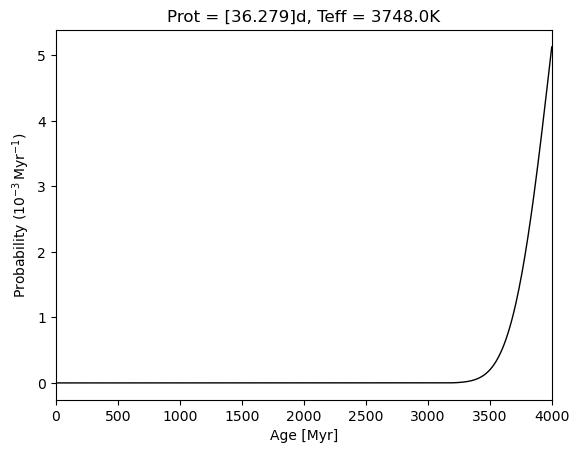

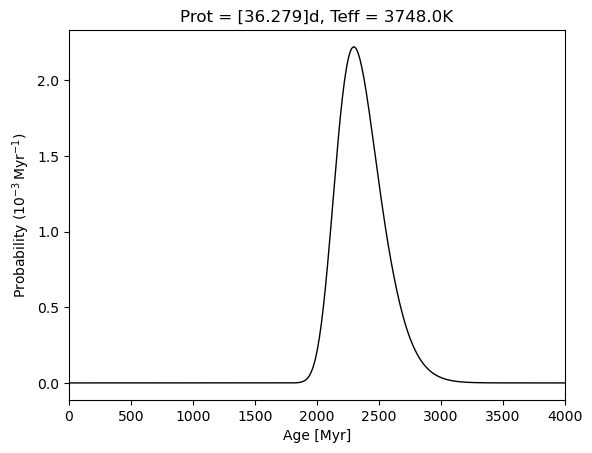

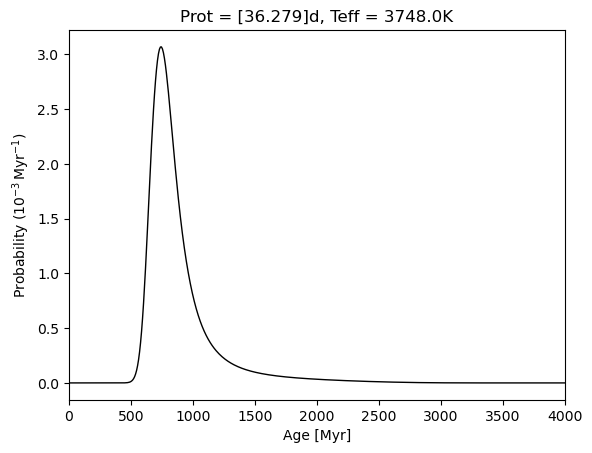

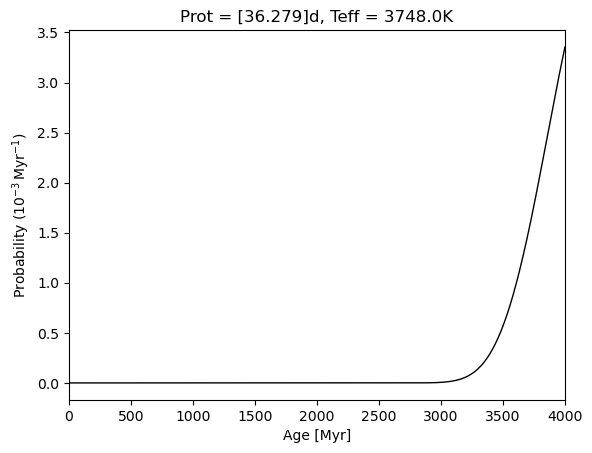

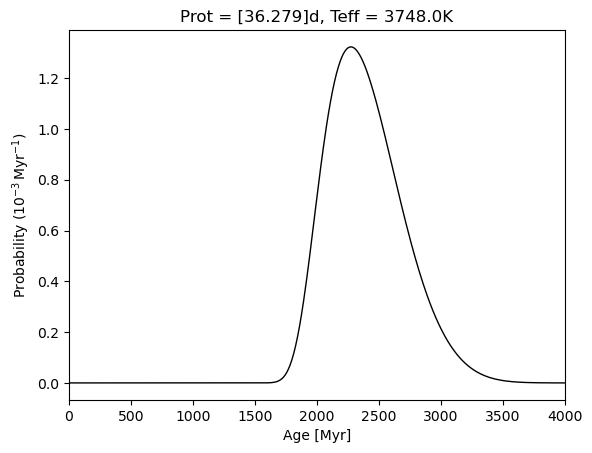

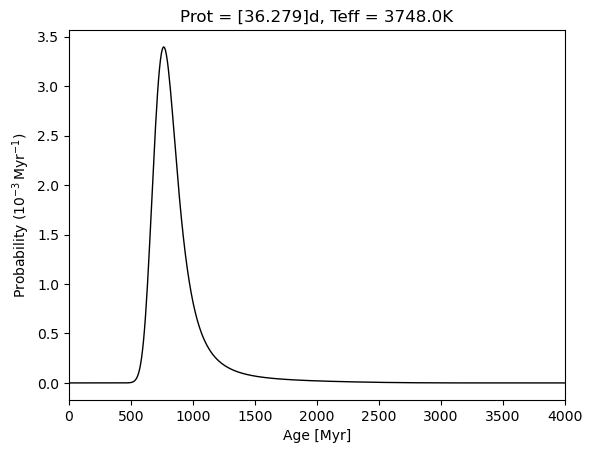

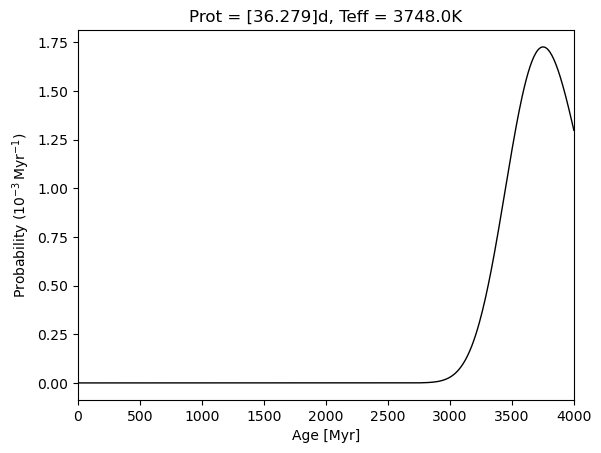

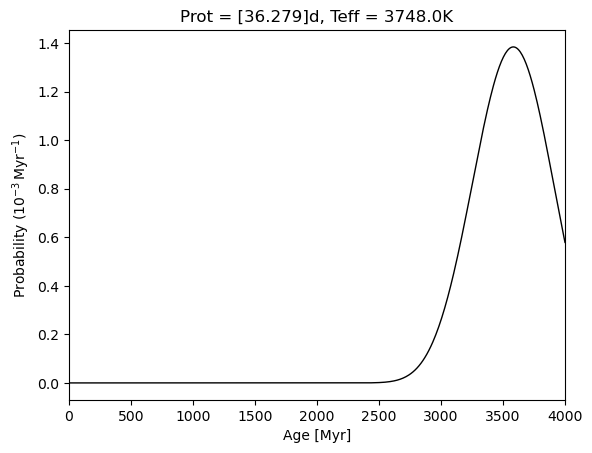

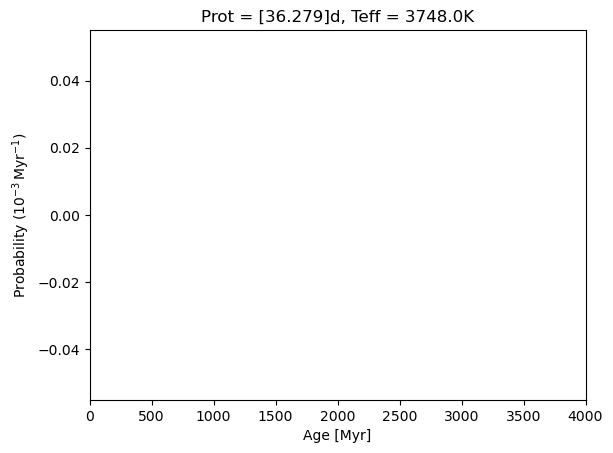

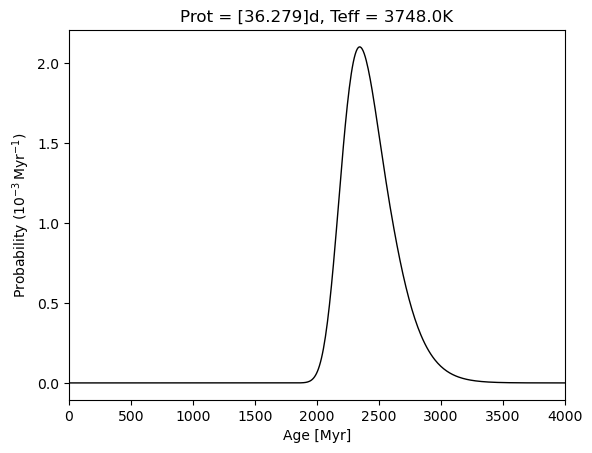

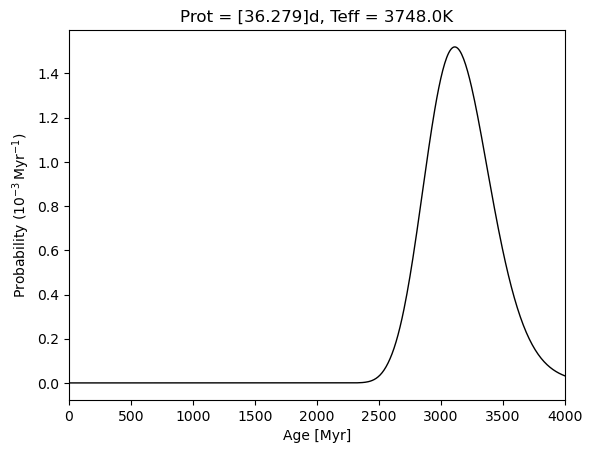

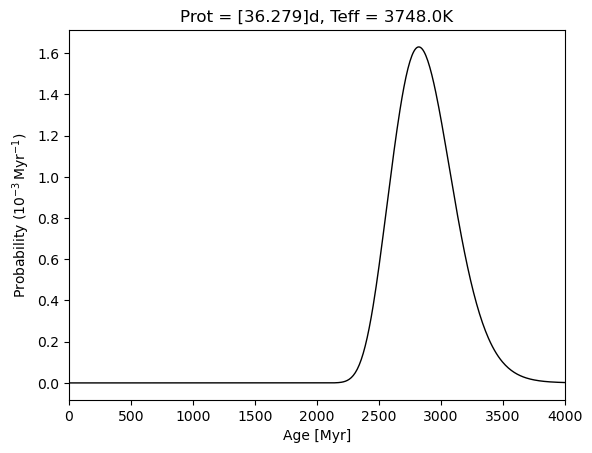

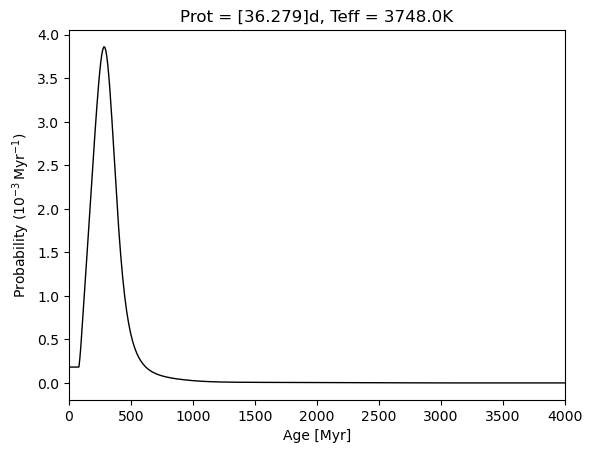

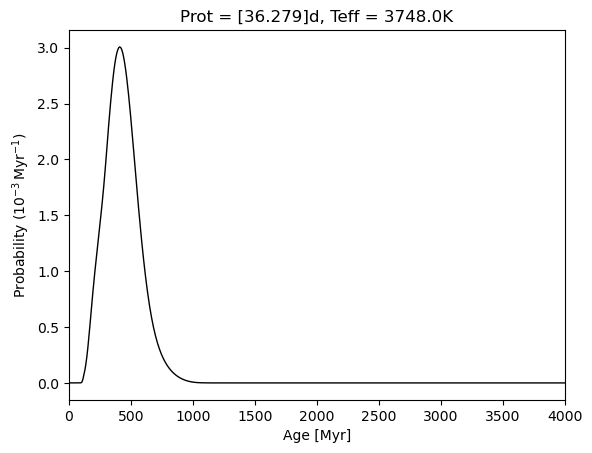

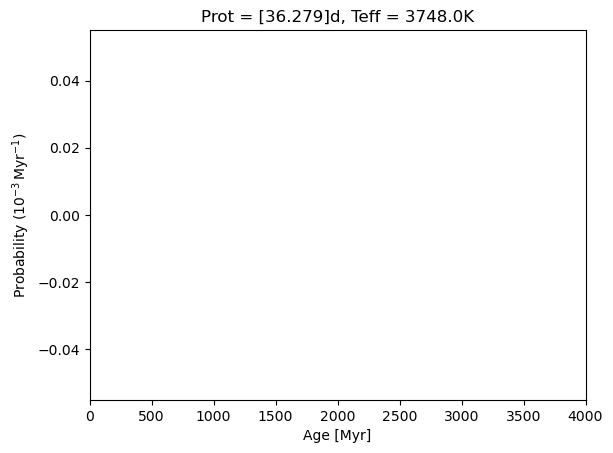

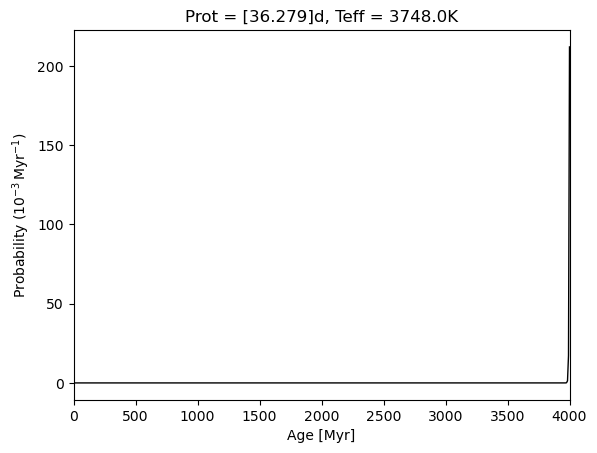

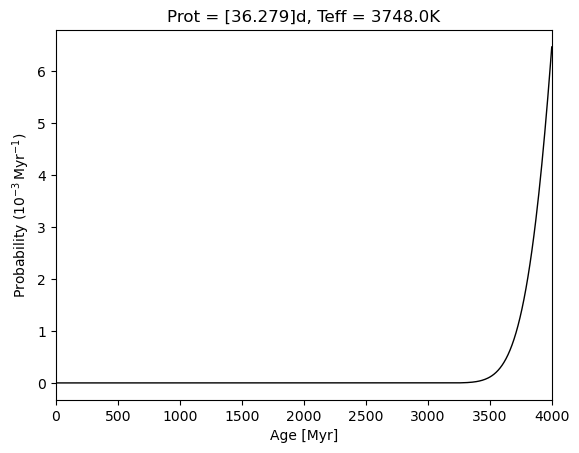

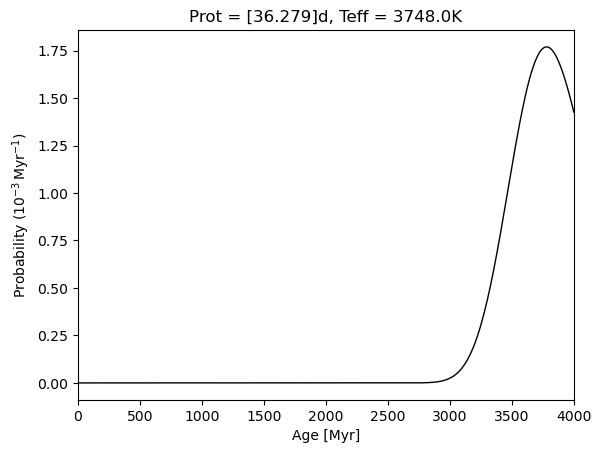

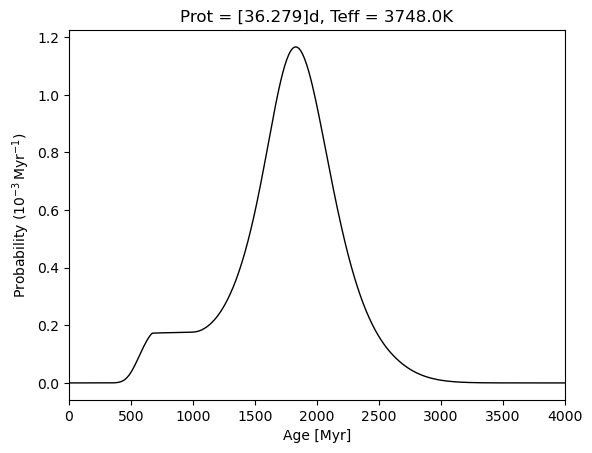

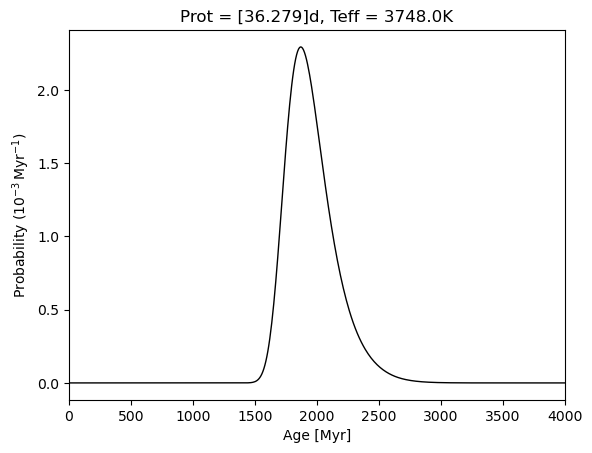

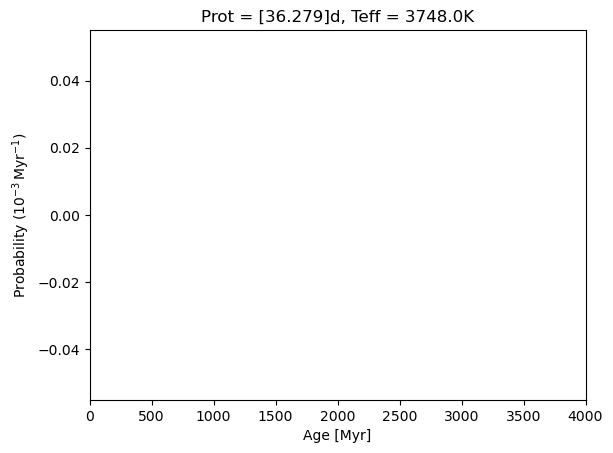

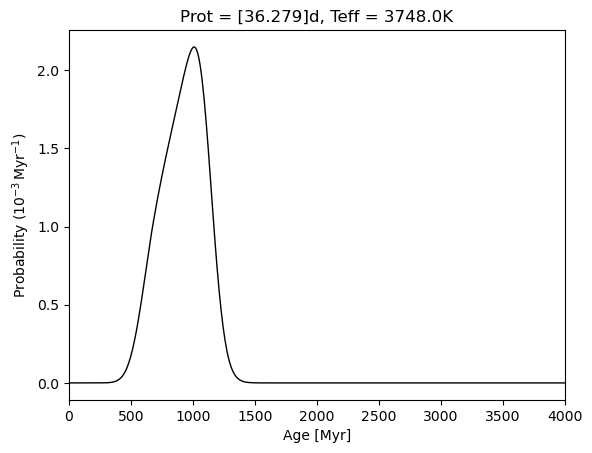

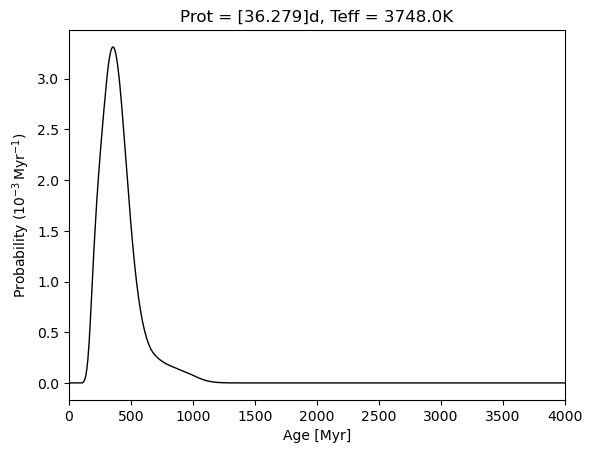

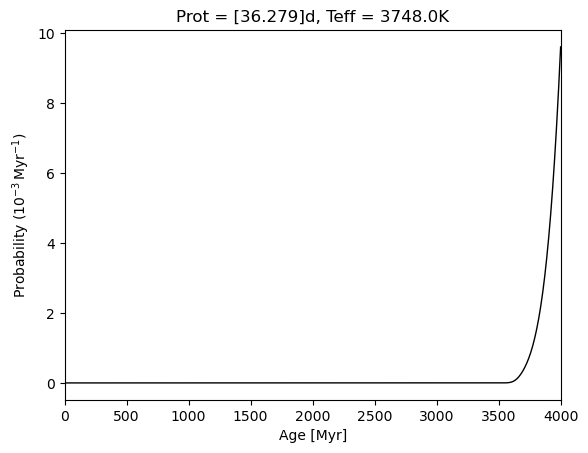

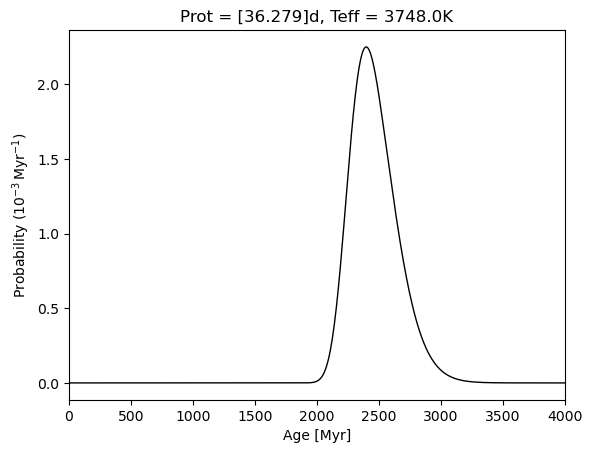

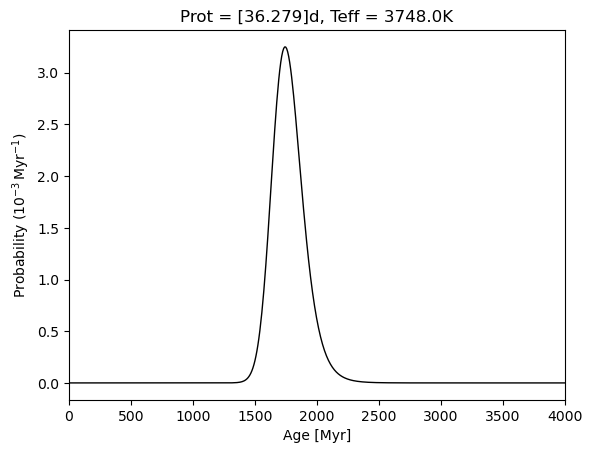

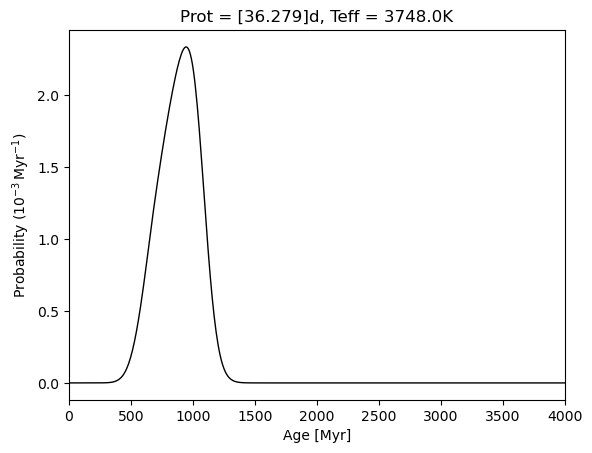

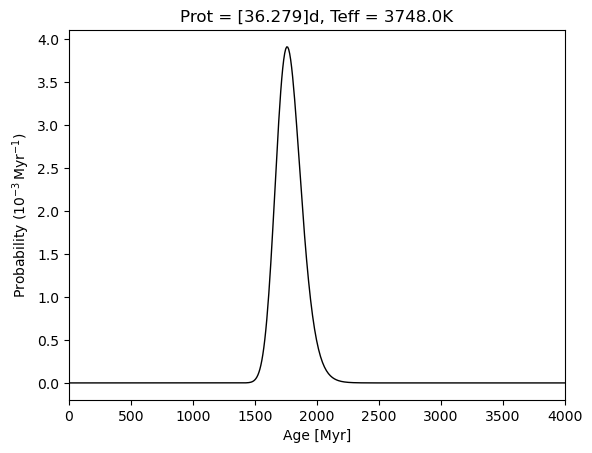

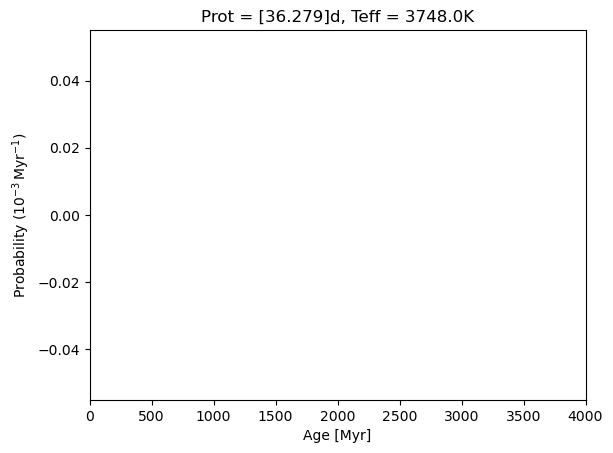

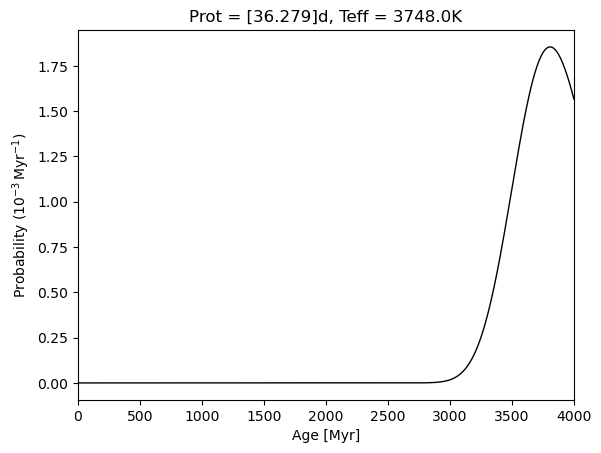

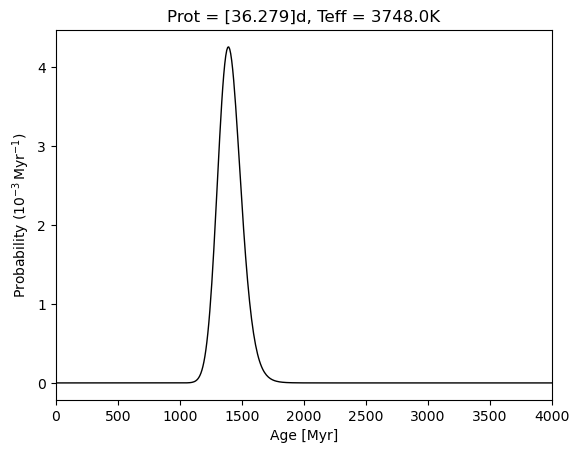

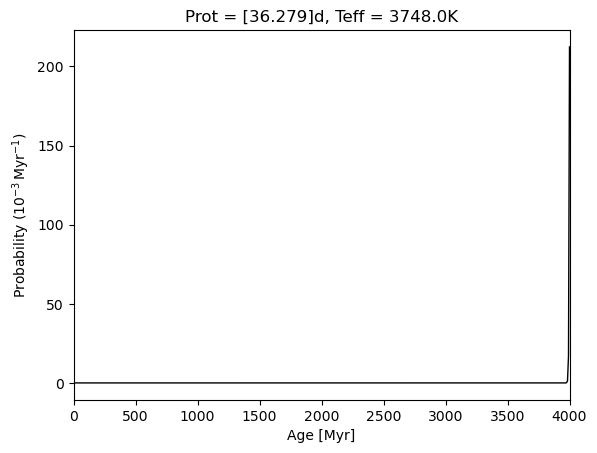

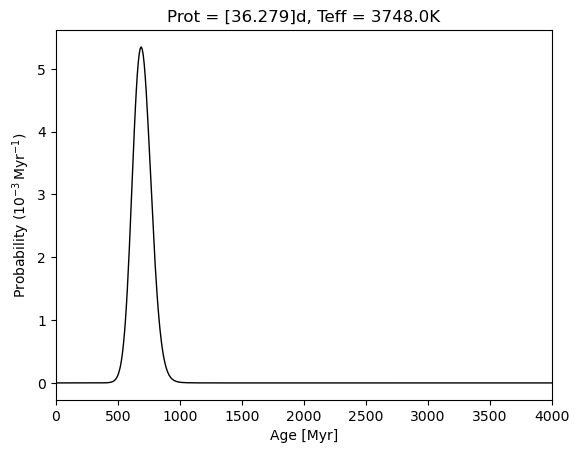

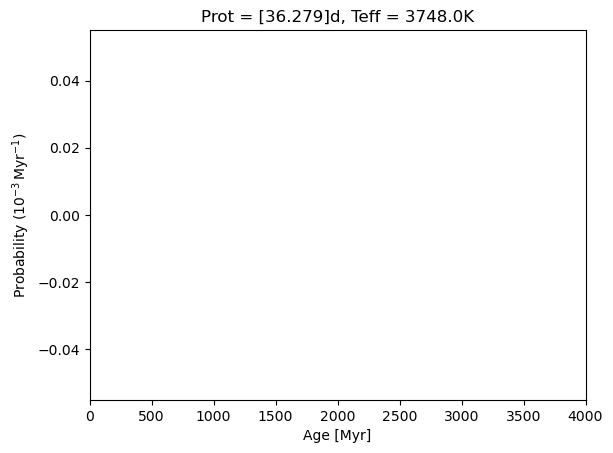

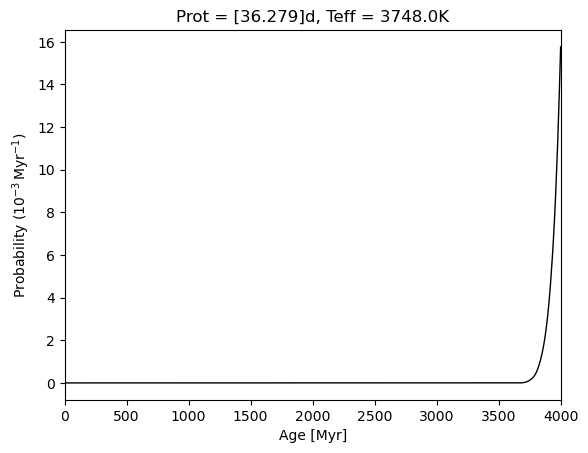

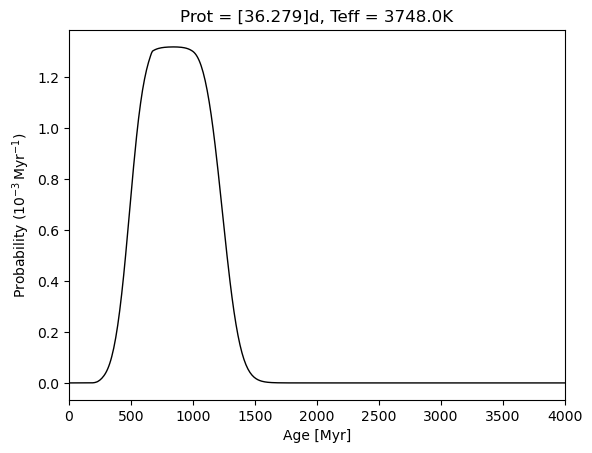

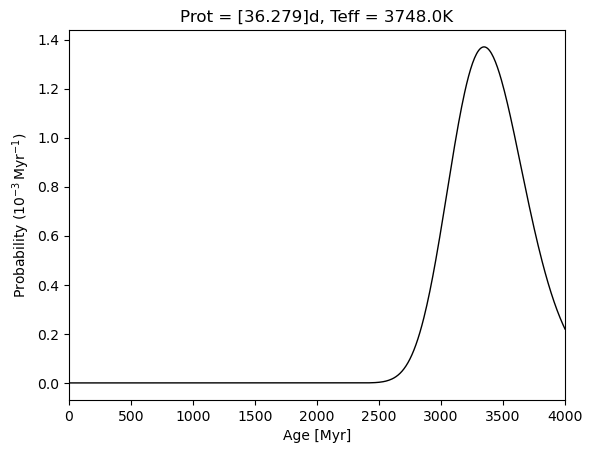

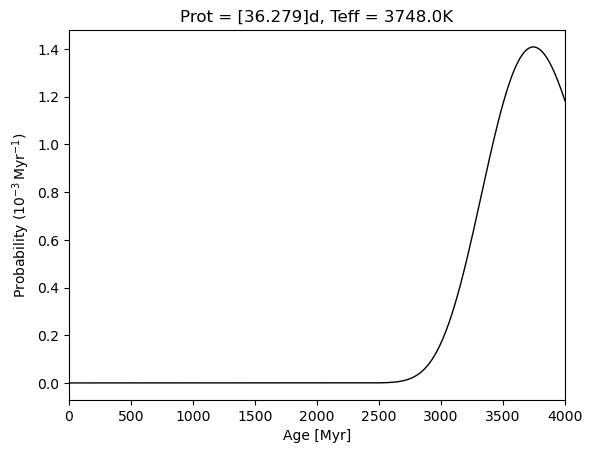

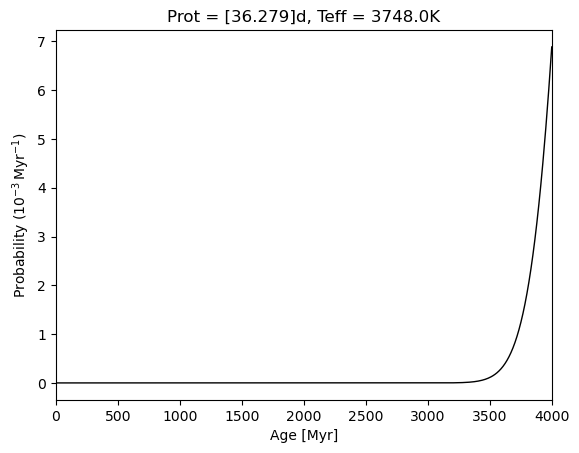

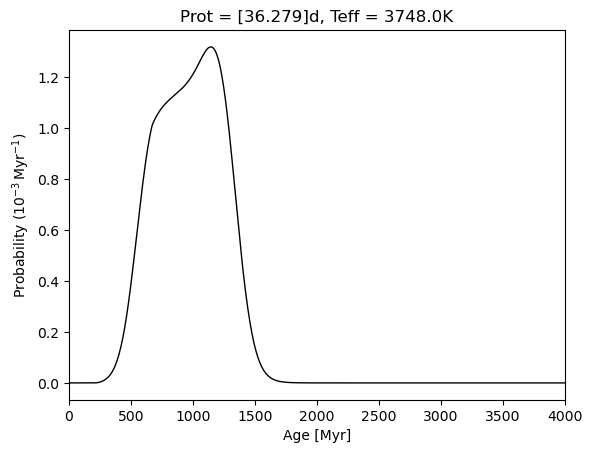

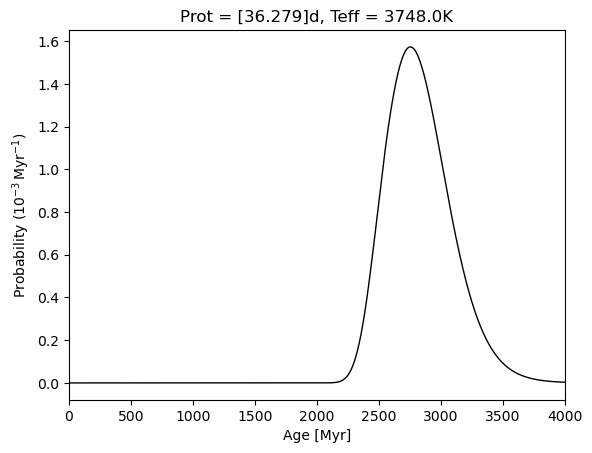

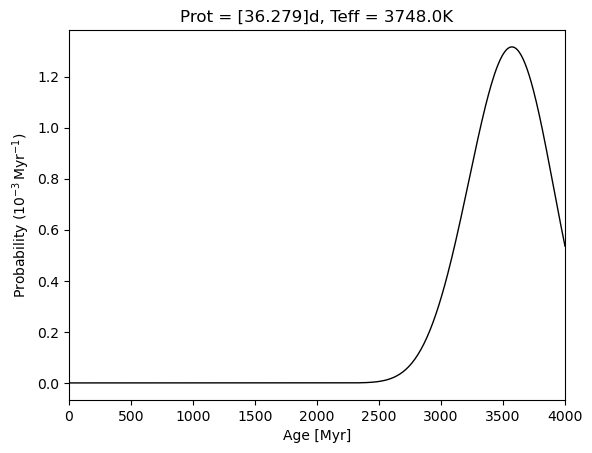

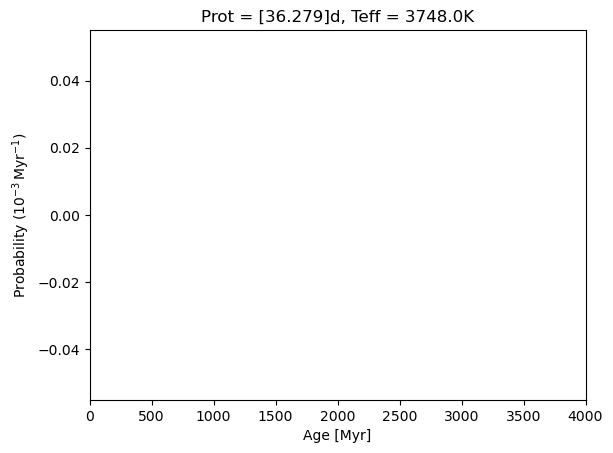

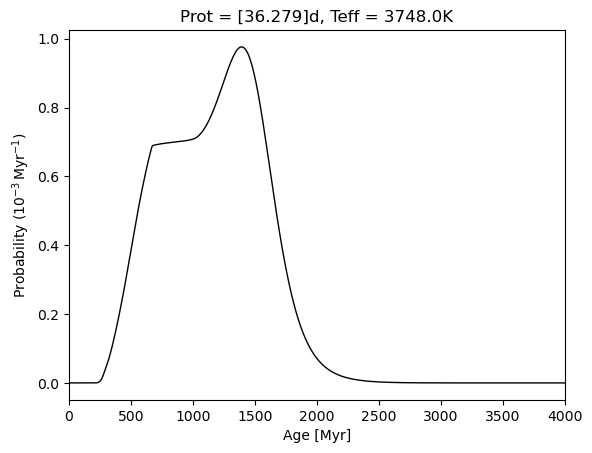

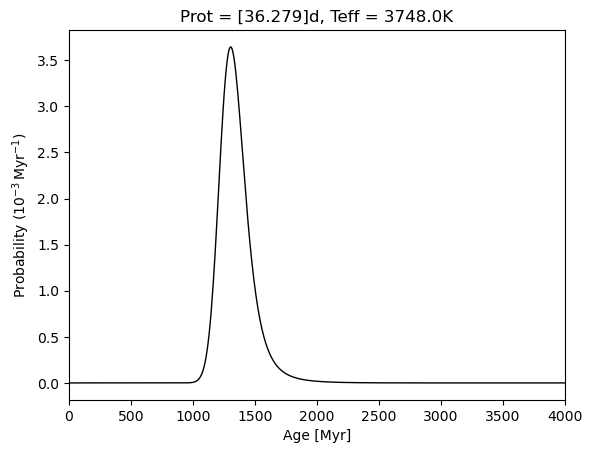

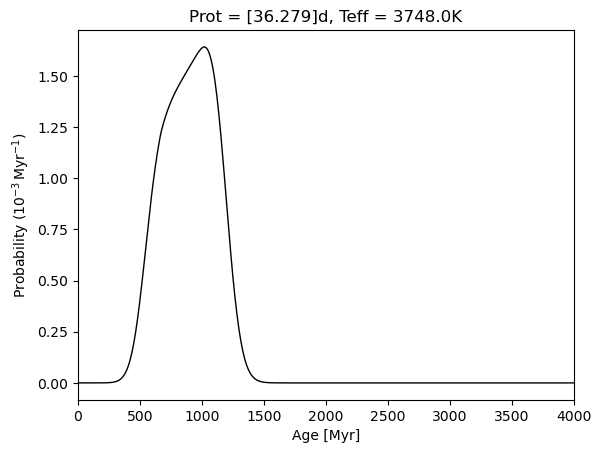

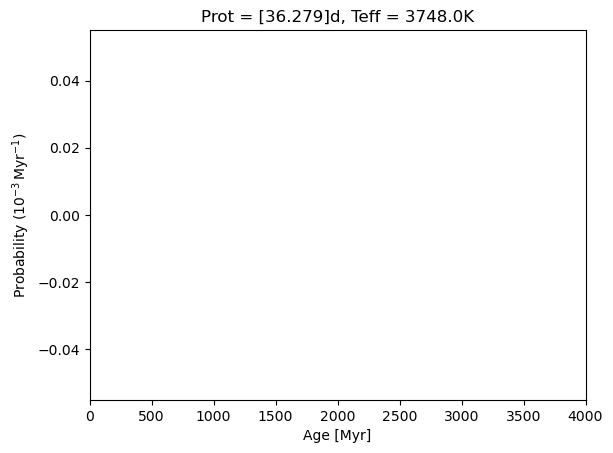

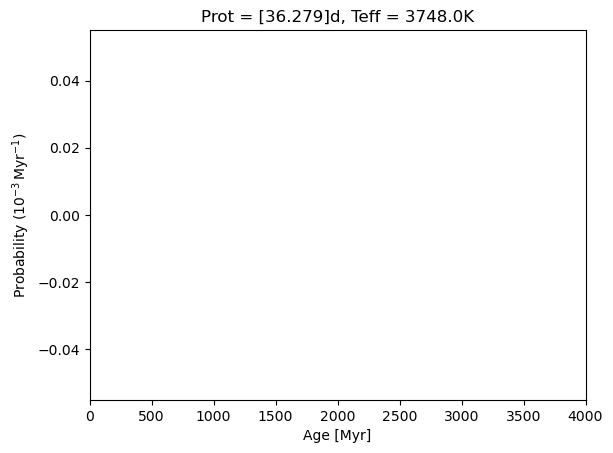

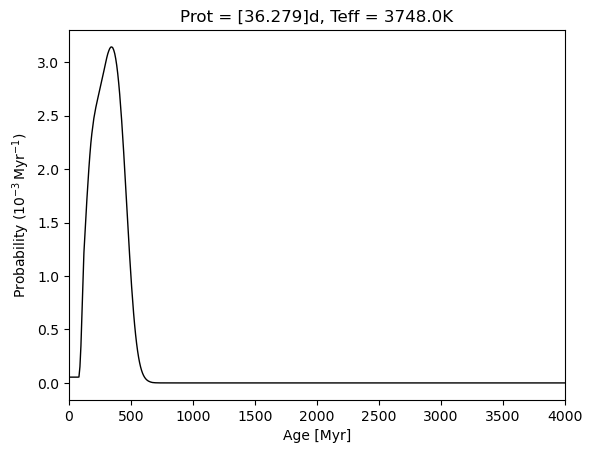

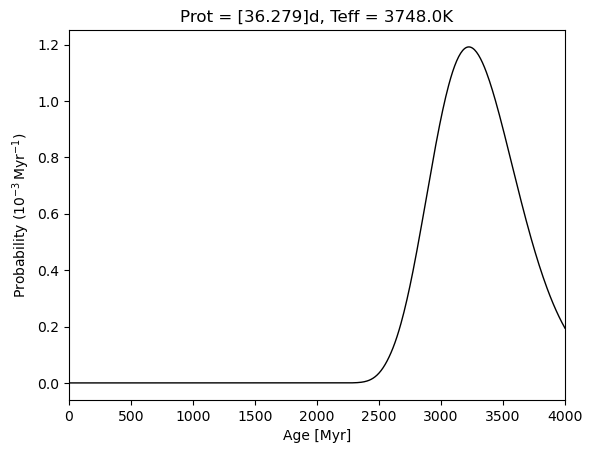

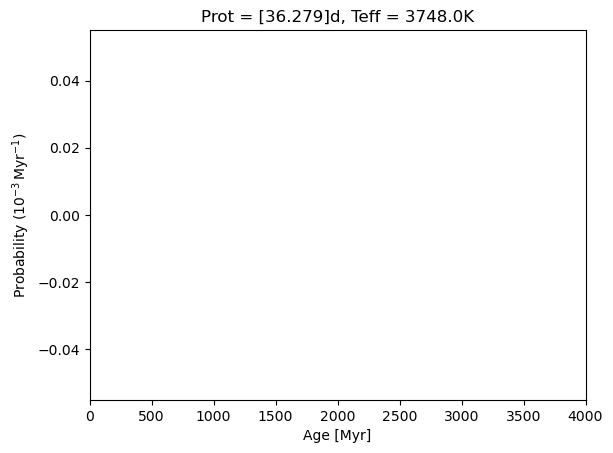

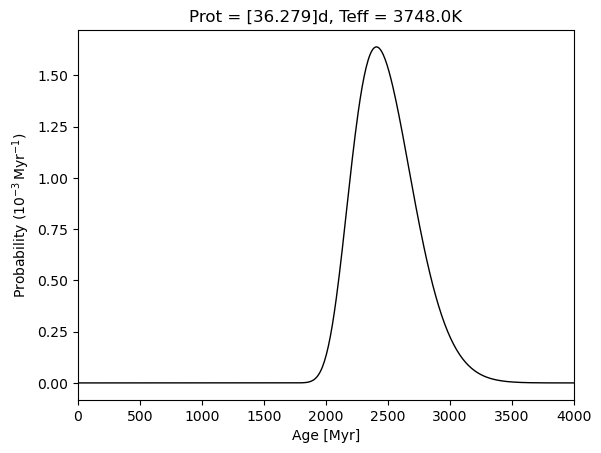

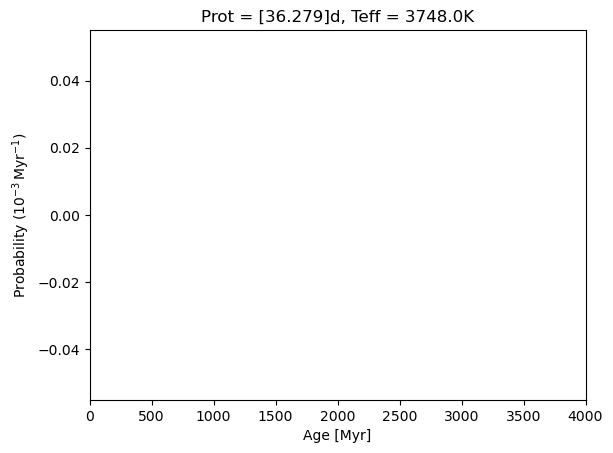

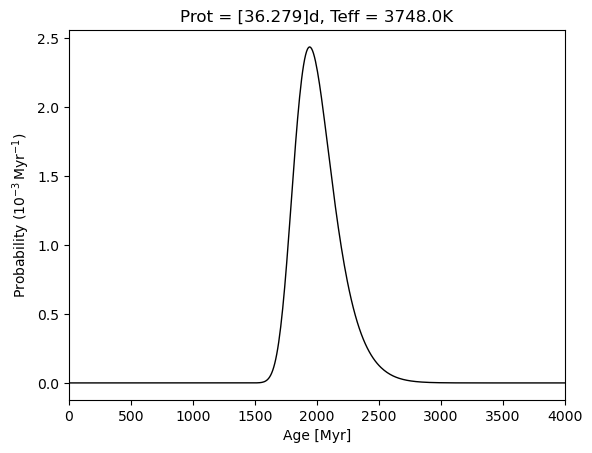

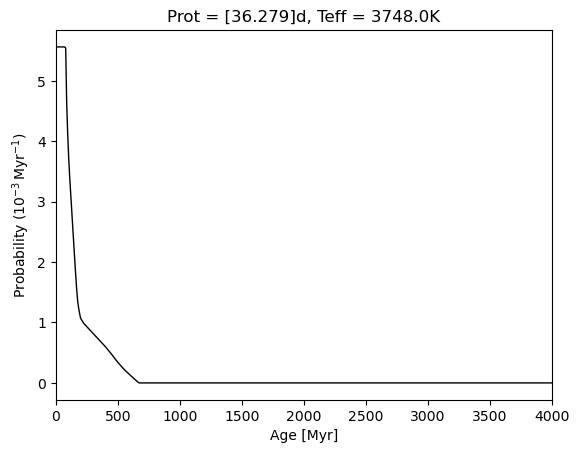

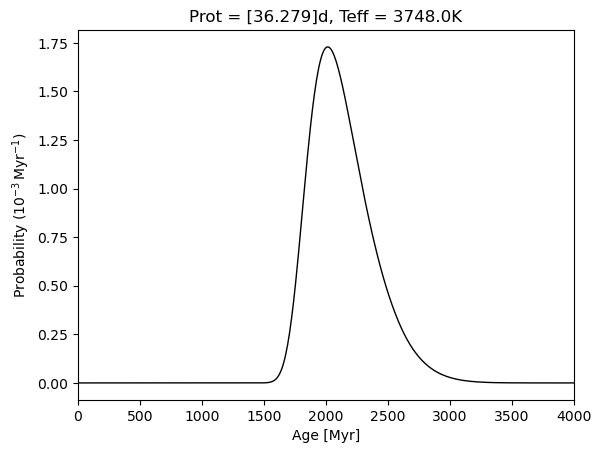

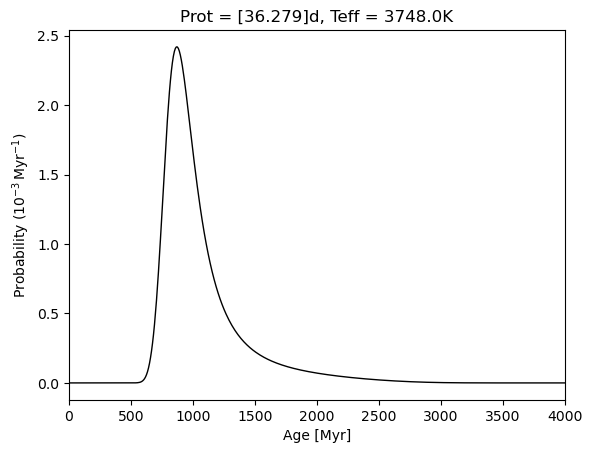

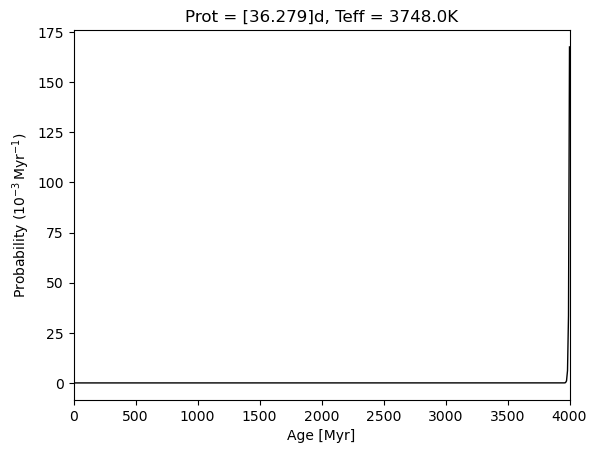

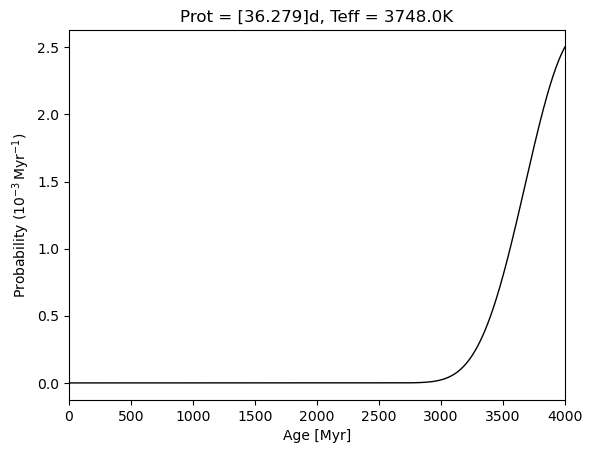

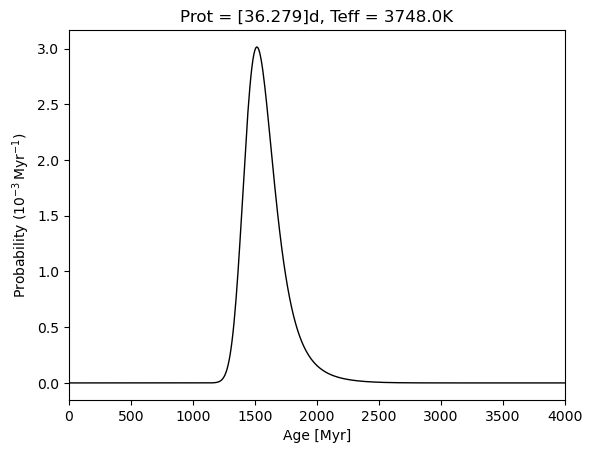

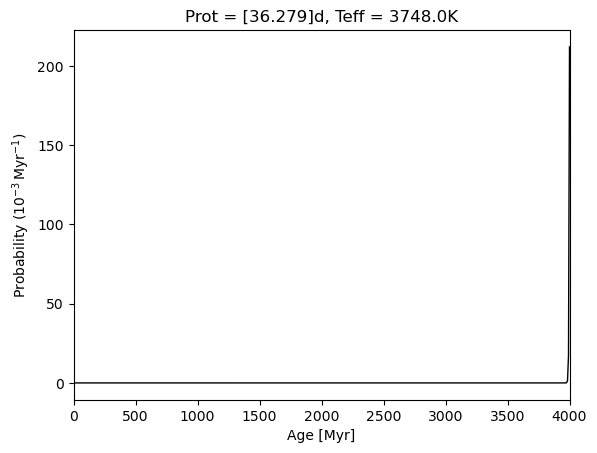

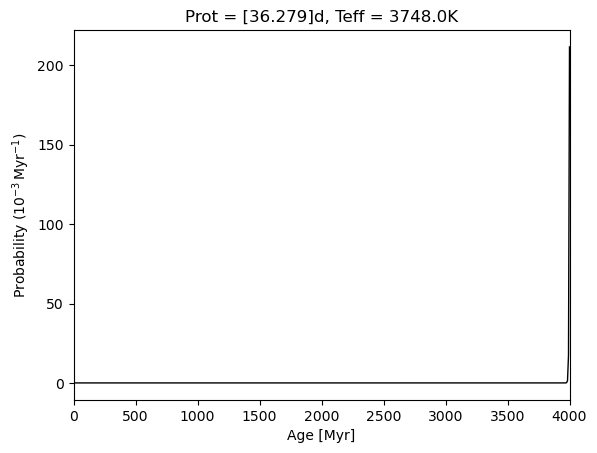

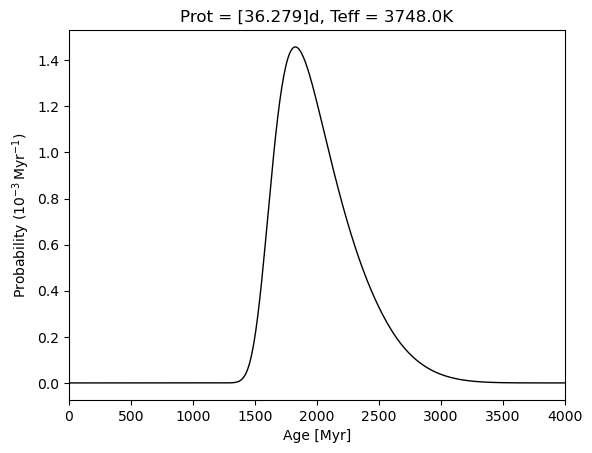

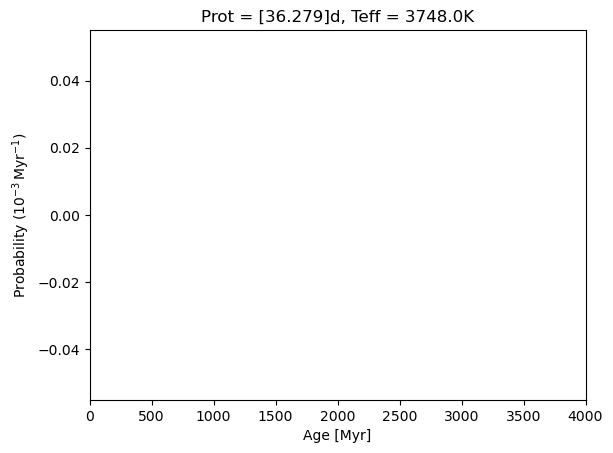

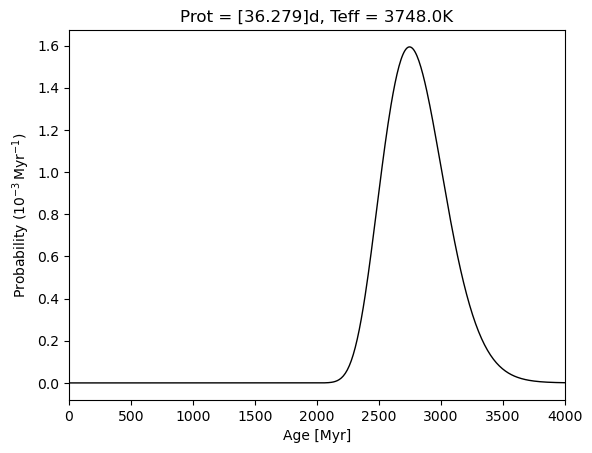

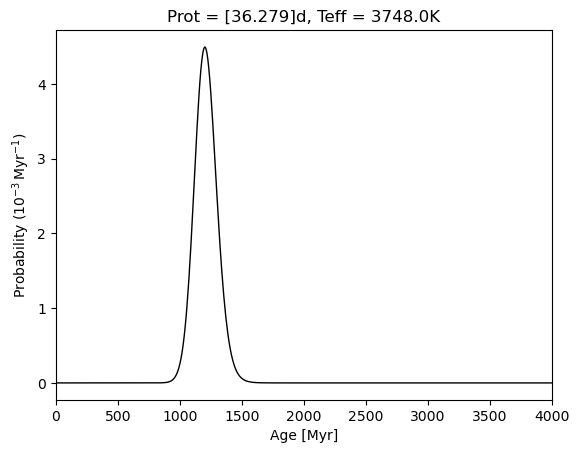

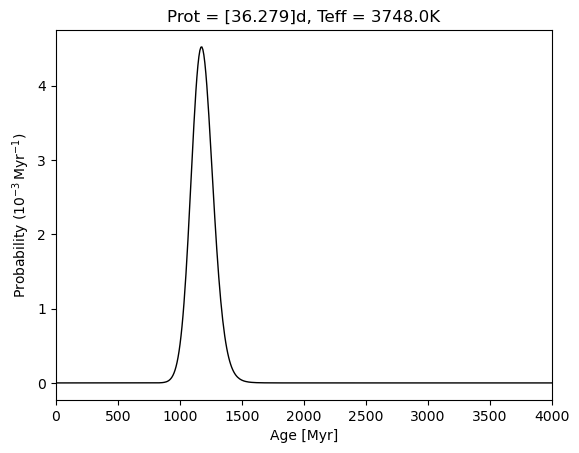

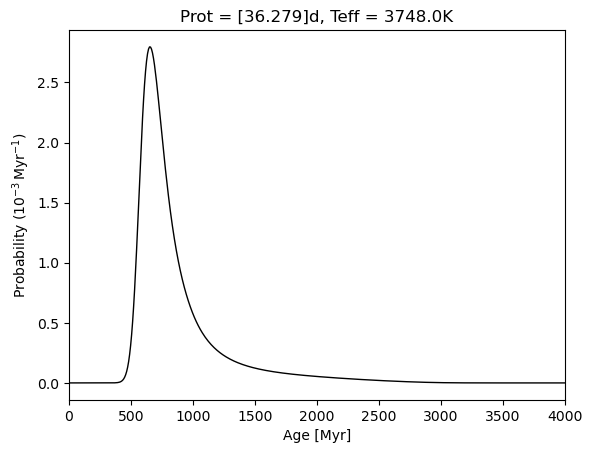

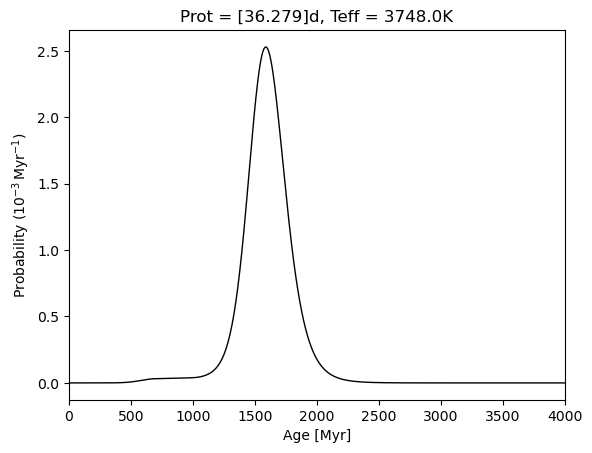

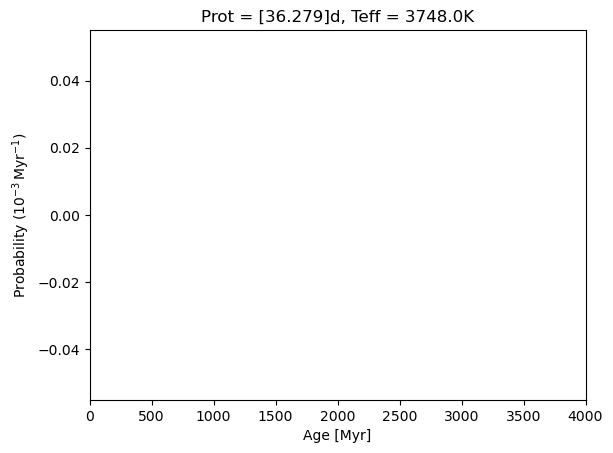

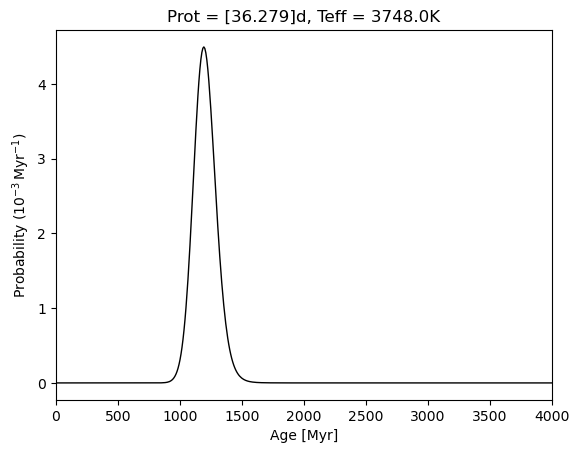

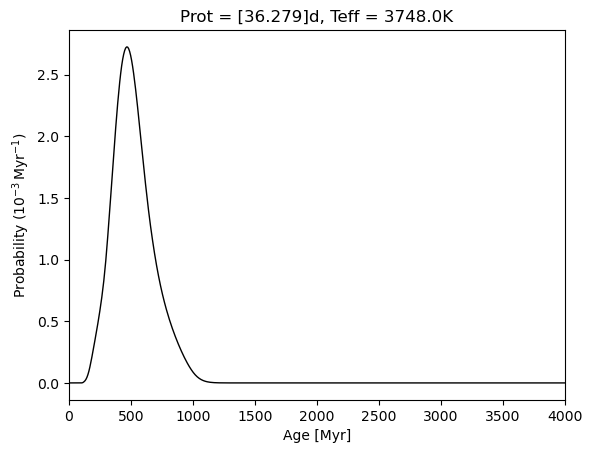

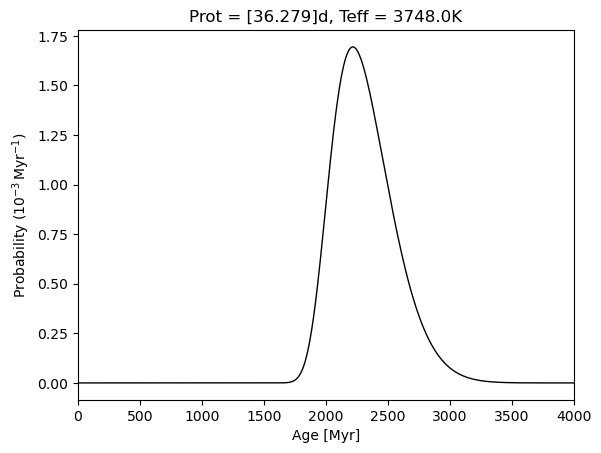

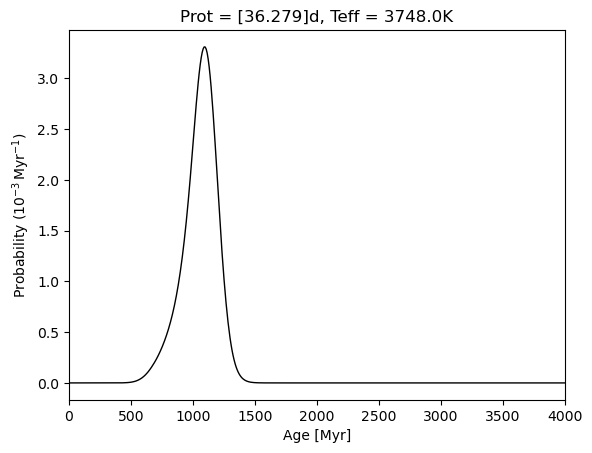

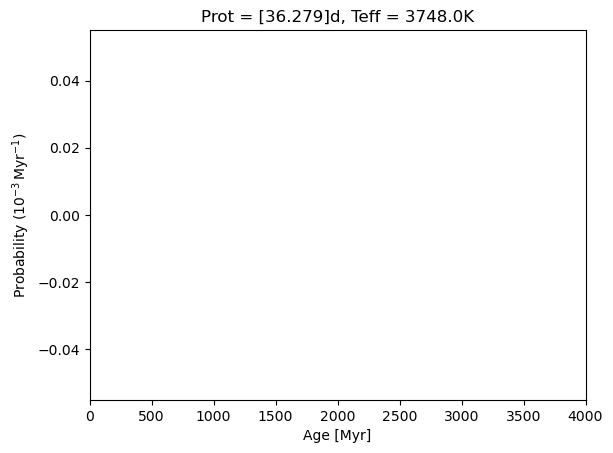

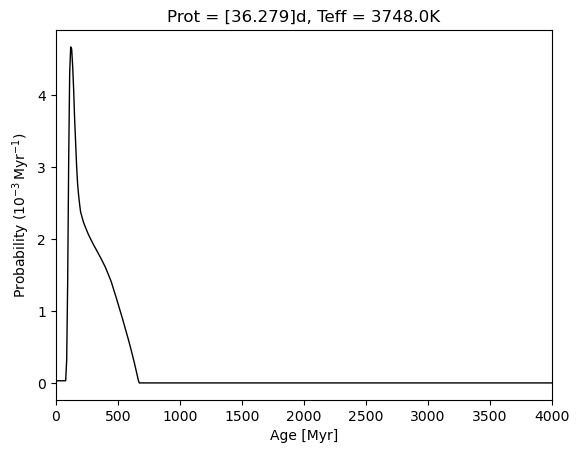

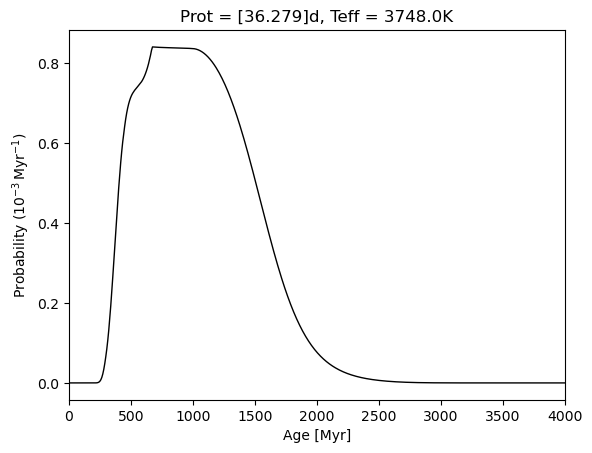

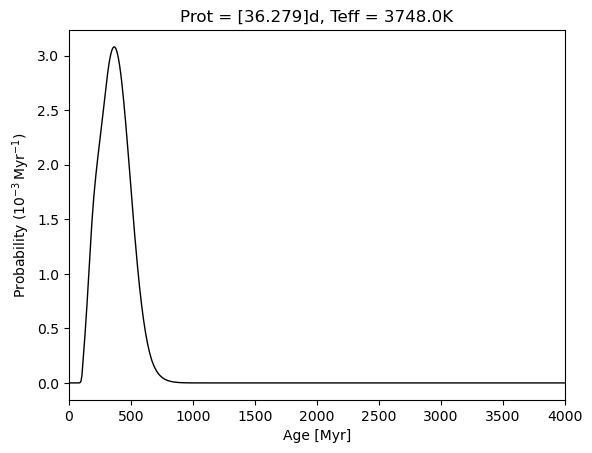

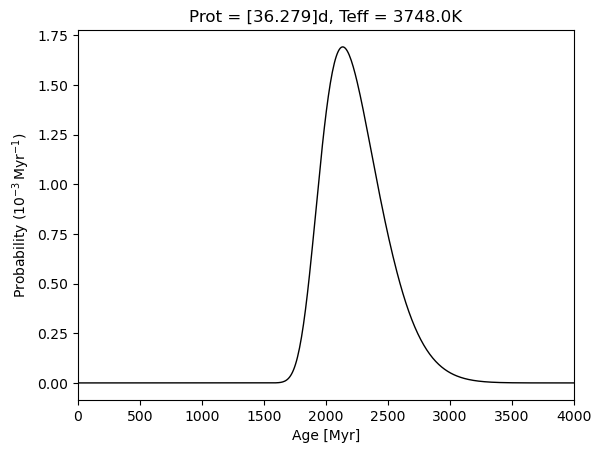

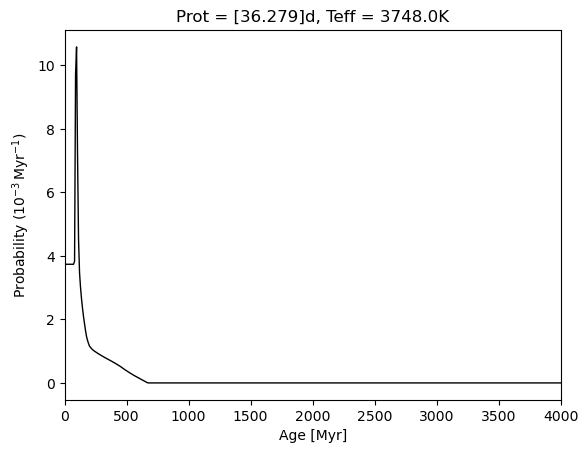

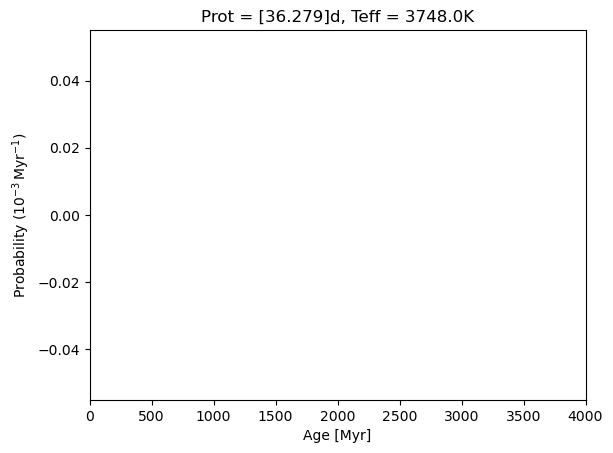

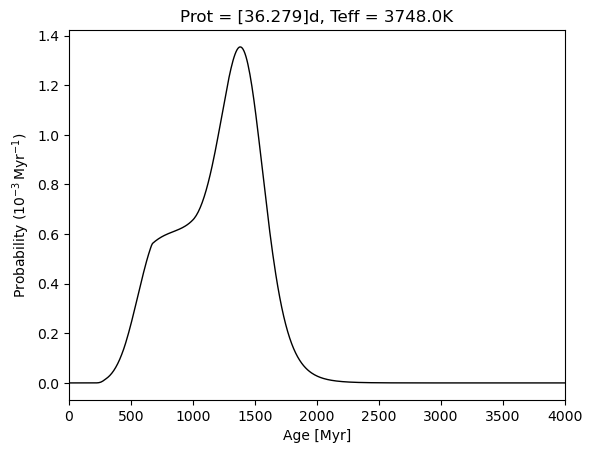

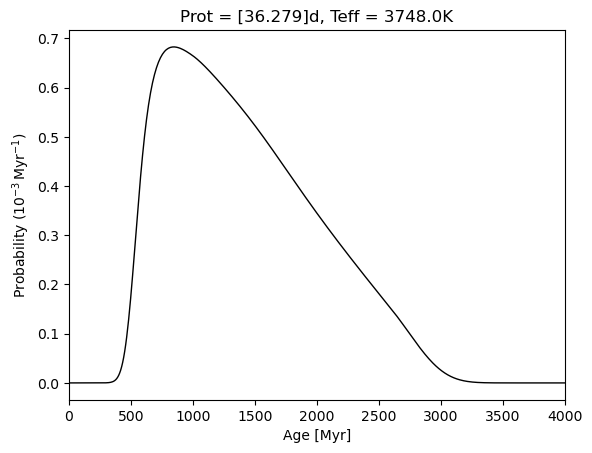

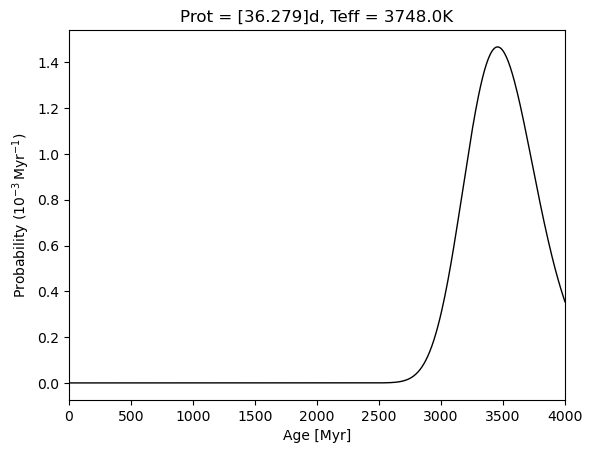

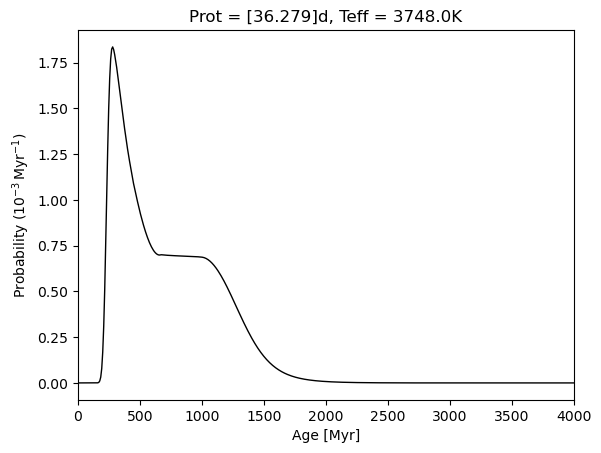

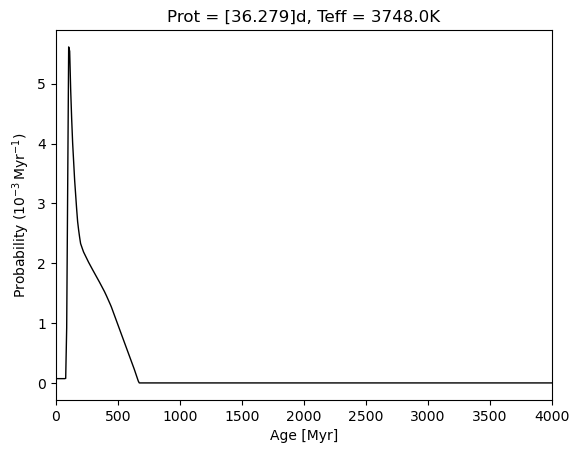

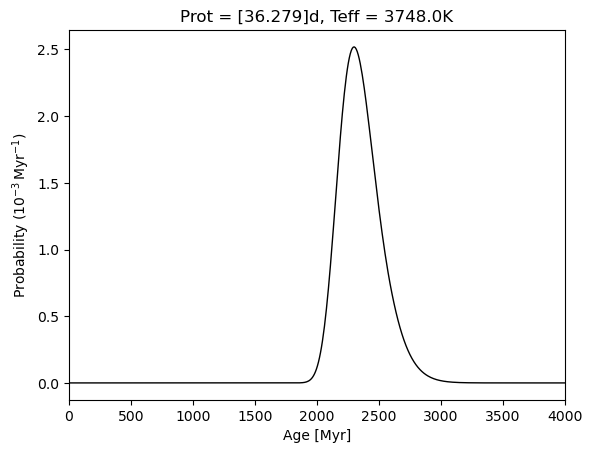

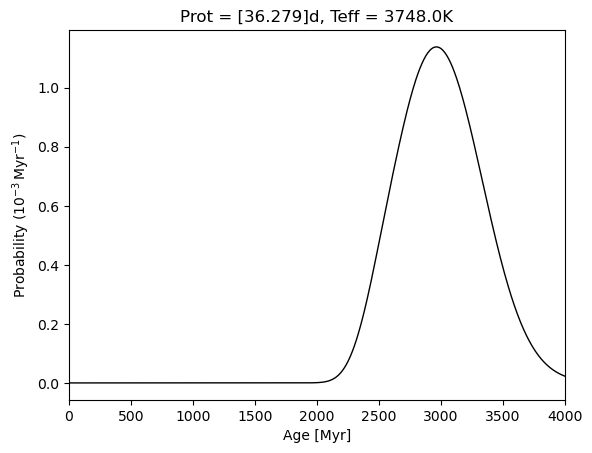

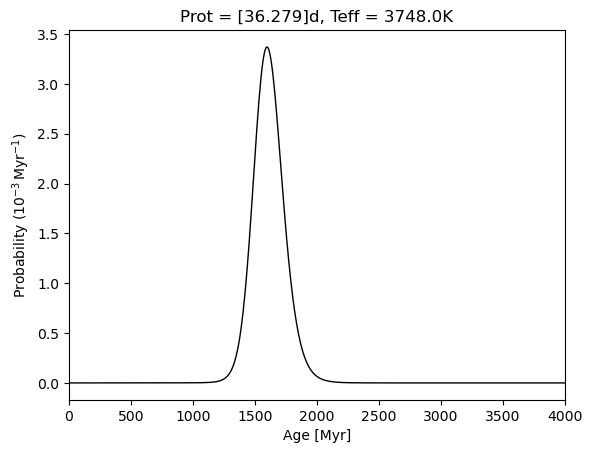

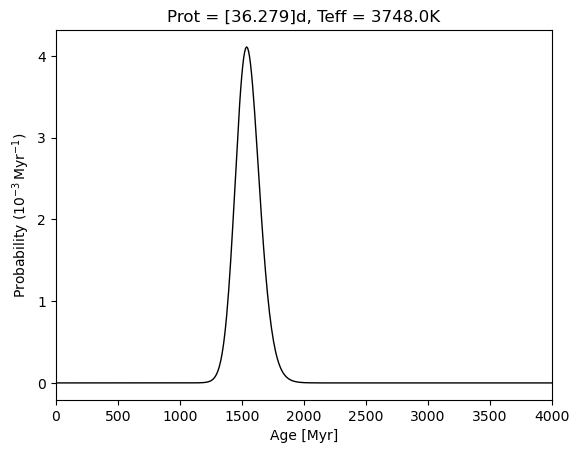

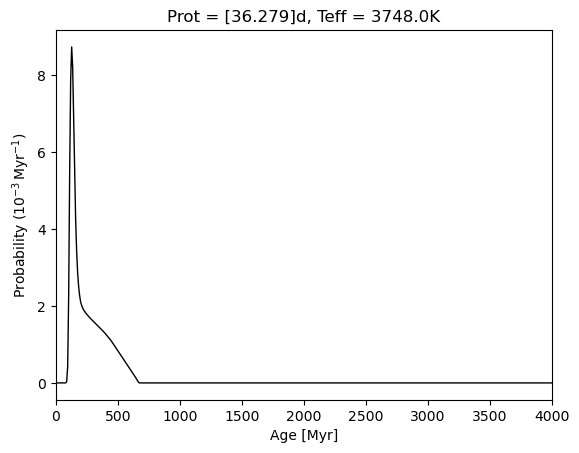

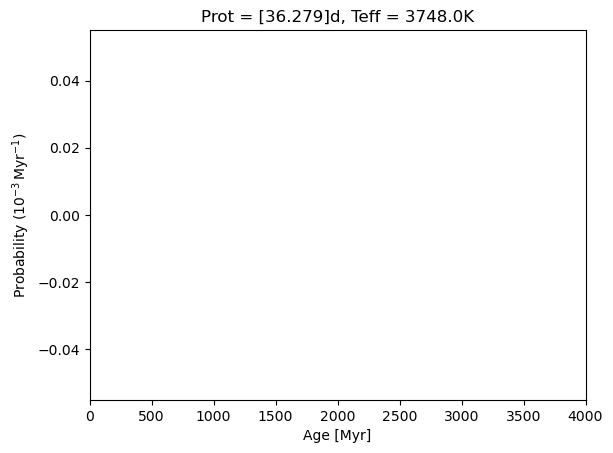

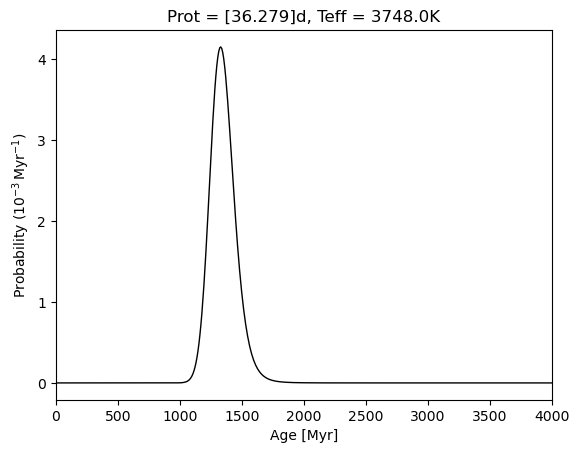

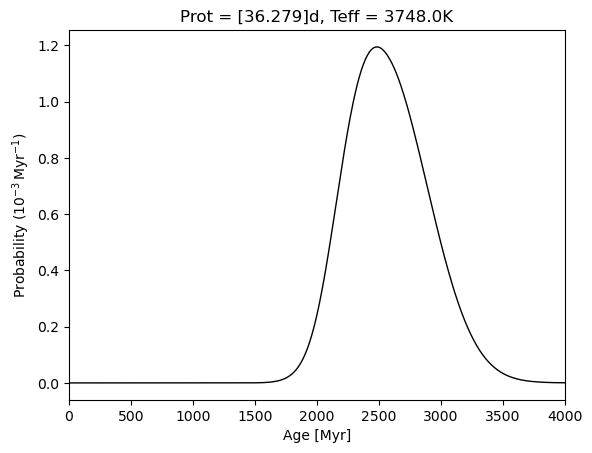

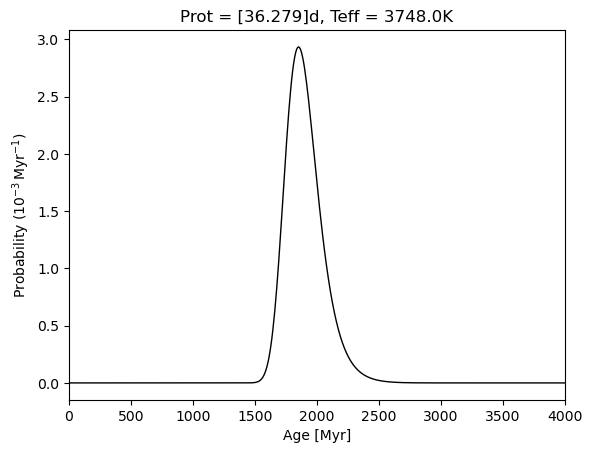

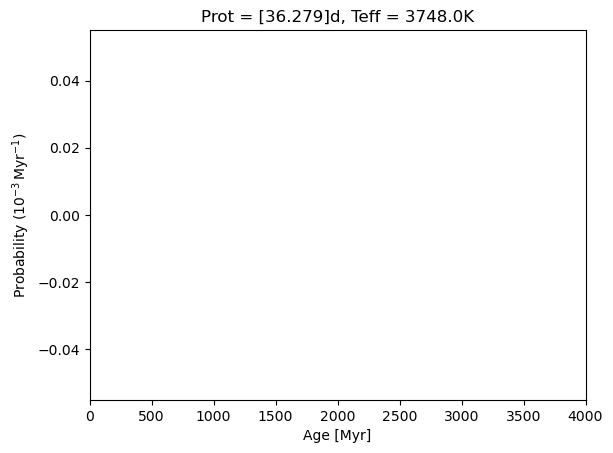

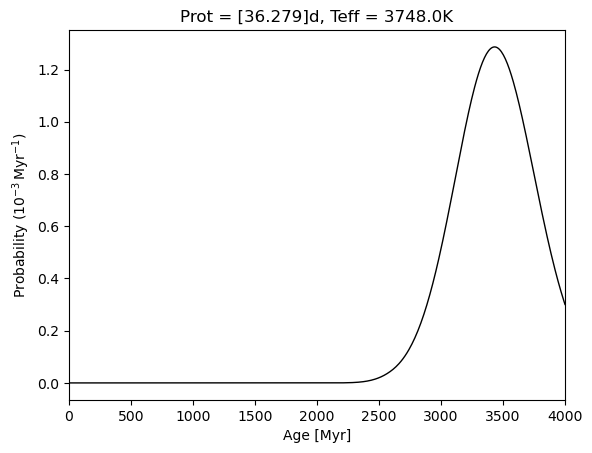

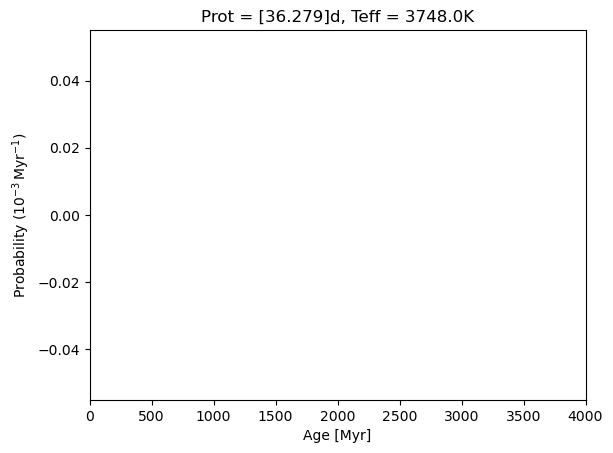

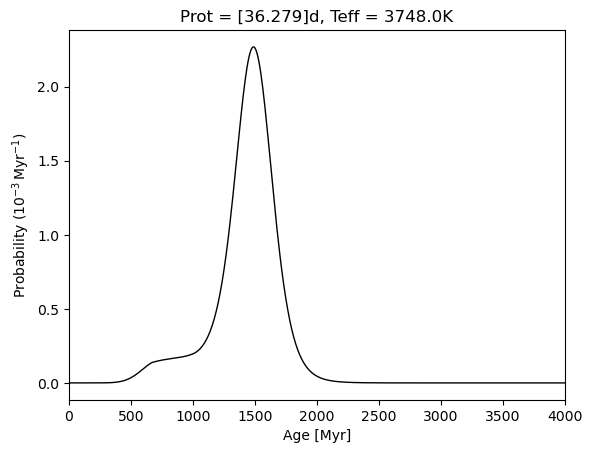

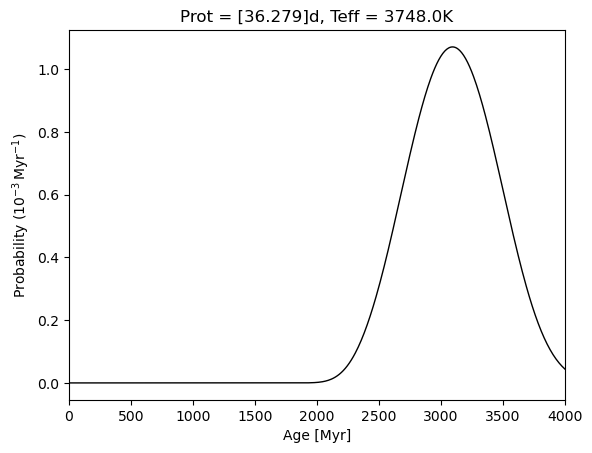

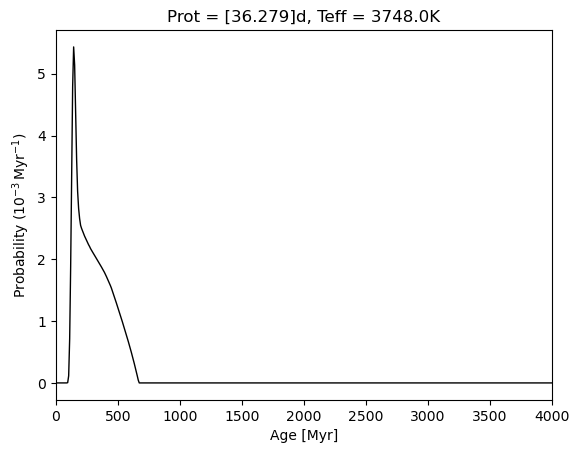

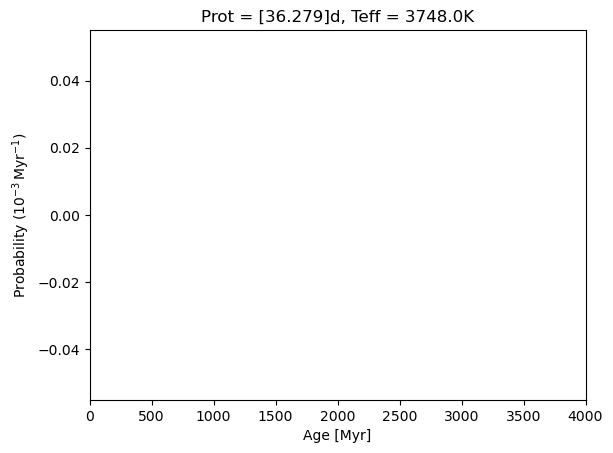

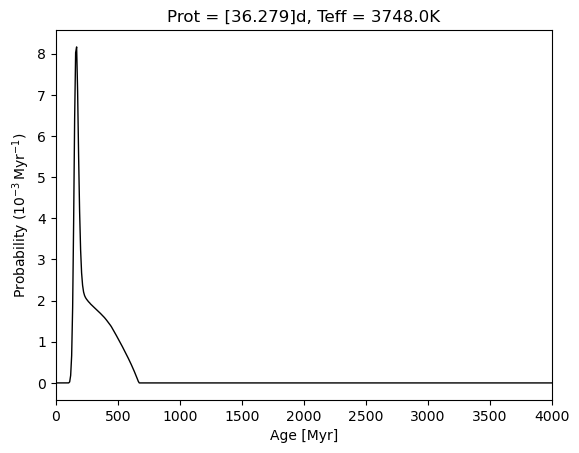

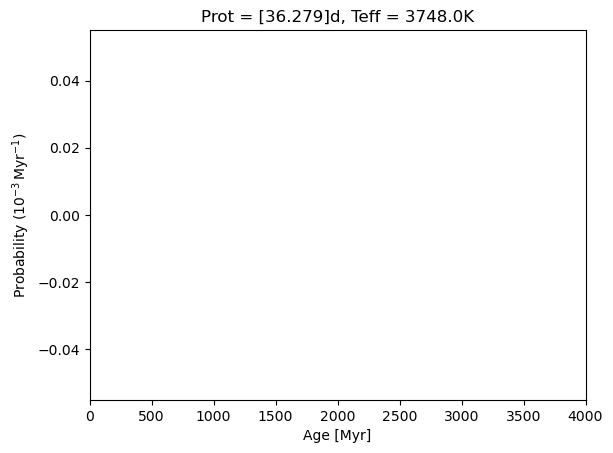

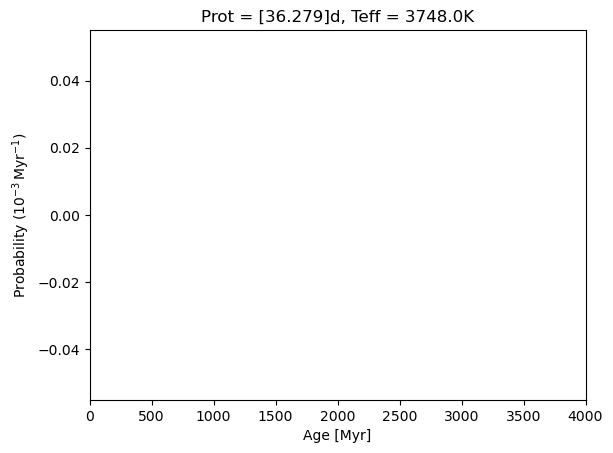

In [18]:
import matplotlib.pyplot as plt

for i in range(len(k2_star_df)):
    age_grid = k2_star_df['age_grid'][i]
    age_posterior = k2_star_df['age_posterior'][i]
    fig, ax = plt.subplots()
    ax.plot(age_grid, 1e3*age_posterior, c='k', lw=1)
    ax.update({
        'xlabel': 'Age [Myr]',
        'ylabel': 'Probability ($10^{-3}\,$Myr$^{-1}$)',
        'title': f'Prot = {Prot}d, Teff = {Teff}K',
        'xlim': [0,4000]
    })
    plt.show()